In [1]:
# Phase 0–1: Environment + Topology + Producer Setup (with KB/MB)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
import random, math, pprint
from scipy.optimize import minimize, Bounds, LinearConstraint

# -----------------------------
# Global Simulation Parameters
# -----------------------------
np.random.seed(42)
random.seed(42)

SIM_DURATION_SEC = 300          # total simulated time (e.g., 5 min)
TIME_WINDOW = 5               # window granularity (seconds)
WARMUP_WINDOWS = 4              # number of warm-up intervals before adaptive routing

# EWMA on delays toggle
# 0.0 → OFF (baseline / instantaneous delays)
# 0.25 → ON (light smoothing)
BETA_DELAY = 0.25

# Knobs for time-varying link/broker dynamics (amplitude, period, noise)
# These values are only read by vary_* functions via their default args.
LINK_AMP, LINK_PERIOD, LINK_NOISE       = 0.15,  60, 0.02
BROKER_AMP, BROKER_PERIOD, BROKER_NOISE = 0.25, 120, 0.03

# (optional) root folder for saving per-run figures later
SAVE_ROOT = "results"



# utility helpers
def safe_div(x, y, eps=1e-9):
    return x / (y + eps)

def softmin_delays(delays, alpha):
    """return normalized exp(-α * delay)"""
    weights = np.exp(-alpha * np.array(delays))
    return weights / (np.sum(weights) + 1e-9)

# ------------------------------------------------
# Step 1: Brokers, Topics, and Partitions
# ------------------------------------------------
# Service Nodes (brokers)
brokers = ['SN1', 'SN2', 'SN3']   # <-- renamed
N_BROKERS = len(brokers)

topics = {
    't1': 12,
    't2': 9,
    't3': 6,
    't4': 3
}

# Round-robin topic partition → broker mapping
partition_to_broker = {}
broker_partition_map = defaultdict(list)

for topic, n_parts in topics.items():
    for p in range(n_parts):
        b = brokers[p % N_BROKERS]
        partition_to_broker[(topic, p)] = b
        broker_partition_map[b].append((topic, p))

print("Partition → Broker assignment:")
for (topic, p), b in partition_to_broker.items():
    print(f"  {topic}-p{p:02d} → {b}")

# ------------------------------------------------
# Step 2: Producers and Topic Preferences
# ------------------------------------------------
N_PRODUCERS = 5
producers = [f"P{i}" for i in range(N_PRODUCERS)]

producer_topic_pref = {
    'P0': ['t1', 't2'],
    'P1': ['t1'],
    'P2': ['t2', 't3'],
    'P3': ['t3', 't4'],
    'P4': ['t1', 't4']
}

# Topic-level message rates and average sizes (unit, value)
topic_msg_rate = {
    't1': 50,   # msgs/sec
    't2': 30,
    't3': 15,
    't4': 10
}

topic_avg_size = {
    't1': ("KB", 2),     # telemetry
    't2': ("KB", 2),     # logs
    't3': ("MB", 2),     # video (~2 MB)
    't4': ("KB", 1)      # alerts
}

# Convert to numeric (KB) just for summary display
topic_size_kb = {
    t: (v * 1024 if u == "MB" else v)
    for t, (u, v) in topic_avg_size.items()
}

# summary DataFrame
df_topics = pd.DataFrame({
    'unit': [u for (u, _) in topic_avg_size.values()],
    'avg_msg_size': [v for (_, v) in topic_avg_size.values()],
    'avg_size_KB_equiv': [topic_size_kb[t] for t in topic_avg_size.keys()],
    'msg_rate(msg/s)': [topic_msg_rate[t] for t in topic_avg_size.keys()]
}, index=topic_avg_size.keys())

display(df_topics)

print("\nProducer → Topic preferences:")
pprint.pprint(producer_topic_pref)
# Exact notebook-style figure export directory
from pathlib import Path
FIG_DIR = Path('WiOpt26_Exact_Notebook_Figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Notebook-style figures will be saved to: {FIG_DIR.resolve()}')


Partition → Broker assignment:
  t1-p00 → SN1
  t1-p01 → SN2
  t1-p02 → SN3
  t1-p03 → SN1
  t1-p04 → SN2
  t1-p05 → SN3
  t1-p06 → SN1
  t1-p07 → SN2
  t1-p08 → SN3
  t1-p09 → SN1
  t1-p10 → SN2
  t1-p11 → SN3
  t2-p00 → SN1
  t2-p01 → SN2
  t2-p02 → SN3
  t2-p03 → SN1
  t2-p04 → SN2
  t2-p05 → SN3
  t2-p06 → SN1
  t2-p07 → SN2
  t2-p08 → SN3
  t3-p00 → SN1
  t3-p01 → SN2
  t3-p02 → SN3
  t3-p03 → SN1
  t3-p04 → SN2
  t3-p05 → SN3
  t4-p00 → SN1
  t4-p01 → SN2
  t4-p02 → SN3

Producer → Topic preferences:
{'P0': ['t1', 't2'],
 'P1': ['t1'],
 'P2': ['t2', 't3'],
 'P3': ['t3', 't4'],
 'P4': ['t1', 't4']}
Notebook-style figures will be saved to: /workspace/scratch/66ff433b7b8f/WiOpt26_Exact_Notebook_Figures


,unit,avg_msg_size,avg_size_KB_equiv,msg_rate(msg/s)
t1,KB,2,2,50
t2,KB,2,2,30
t3,MB,2,2048,15
t4,KB,1,1,10


Baseline link capacities (μ̂ in KB/s):
  P0->SN1: 47.49 MB/s
  P0->SN2: 54.64 MB/s
  P0->SN3: 43.12 MB/s
  P1->SN1: 41.16 MB/s
  P1->SN2: 52.02 MB/s
  P1->SN3: 40.41 MB/s
  P2->SN1: 56.65 MB/s
  P2->SN2: 43.64 MB/s
  P2->SN3: 46.08 MB/s
  P3->SN1: 48.64 MB/s
  P3->SN2: 52.24 MB/s
  P3->SN3: 45.84 MB/s
  P4->SN1: 49.12 MB/s
  P4->SN2: 43.99 MB/s
  P4->SN3: 51.85 MB/s
...

Baseline broker capacities (μ in MB/s):
  SN1: 160.75 MB/s, phase=1.07 rad
  SN2: 106.51 MB/s, phase=5.96 rad
  SN3: 196.56 MB/s, phase=5.08 rad

=== Sample of Time-Varying Link Capacities (MB/s) ===

=== Sample of Time-Varying Broker Capacities (MB/s) ===

Defined 11 dynamic environment combinations for upcoming runs.


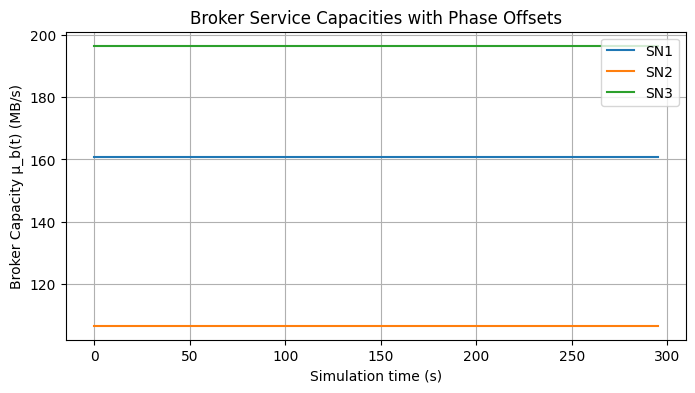

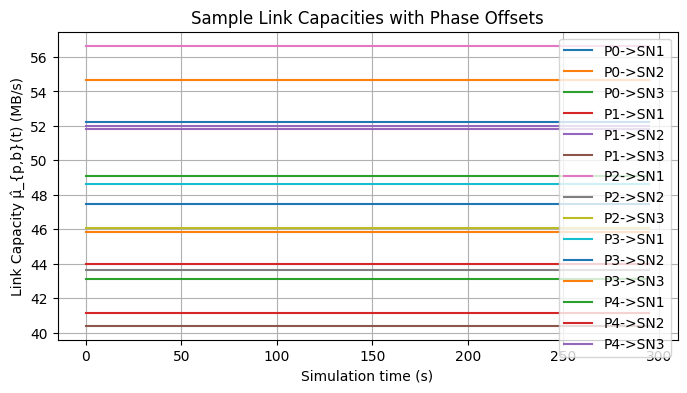

,P0->SN1,P0->SN2,P0->SN3,P1->SN1,P1->SN2,P1->SN3,P2->SN1,P2->SN2,P2->SN3,P3->SN1,P3->SN2,P3->SN3,P4->SN1,P4->SN2,P4->SN3
0,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
5,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
10,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
15,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
20,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
25,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
30,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
35,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
40,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85
45,47.49,54.64,43.12,41.16,52.02,40.41,56.65,43.64,46.08,48.64,52.24,45.84,49.12,43.99,51.85


,SN1,SN2,SN3
0,160.75,106.51,196.56
5,160.75,106.51,196.56
10,160.75,106.51,196.56
15,160.75,106.51,196.56
20,160.75,106.51,196.56
25,160.75,106.51,196.56
30,160.75,106.51,196.56
35,160.75,106.51,196.56
40,160.75,106.51,196.56
45,160.75,106.51,196.56


In [2]:
# ============================================================
# Phase 2 (Updated): Heterogeneous Link and Broker Capacity Modeling + Optional Phase Offsets
# ============================================================

# Toggle for desynchronization between brokers and links
USE_PHASE_OFFSETS = True

# ------------------------------------------------------------
# Step 1: Baseline capacities (KB/s)
# ------------------------------------------------------------
link_base_cap = {}
link_phases = {}
for p in producers:
    for b in brokers:
        base = np.random.uniform(40, 60) * 1024  # KB/s
        link_base_cap[(p, b)] = base
        link_phases[(p, b)] = np.random.uniform(0, 2 * np.pi) if USE_PHASE_OFFSETS else 0.0

broker_base_cap = {}
broker_phases = {}
for b in brokers:
    broker_base_cap[b] = np.random.uniform(100, 200) * 1024  # KB/s
    broker_phases[b] = np.random.uniform(0, 2 * np.pi) if USE_PHASE_OFFSETS else 0.0

print("Baseline link capacities (μ̂ in KB/s):")
for (p, b), val in list(link_base_cap.items())[:15]:
    print(f"  {p}->{b}: {val/1024:.2f} MB/s")
print("...")

print("\nBaseline broker capacities (μ in MB/s):")
for b, val in broker_base_cap.items():
    print(f"  {b}: {val/1024:.2f} MB/s, phase={broker_phases[b]:.2f} rad")

# ------------------------------------------------------------
# Step 2: Capacity functions (with optional freezing)
# ------------------------------------------------------------
FREEZE_CAPS = True   # <<< Set True for constant baseline, False to restore sinusoidal variation

def vary_link_capacity(base_val, t, amp=LINK_AMP, period=LINK_PERIOD, noise_std=LINK_NOISE, phase=0):
    """Time-varying link capacity μ̂_{p,b}(t) with amplitude/period/noise."""
    if FREEZE_CAPS:
        return base_val
    fluct = 1 + amp * np.sin(2 * np.pi * t / period + phase)
    noise  = np.random.normal(0, noise_std)
    return base_val * max(0.2, fluct + noise)

def vary_broker_capacity(base_val, t, amp=BROKER_AMP, period=BROKER_PERIOD, noise_std=BROKER_NOISE, phase=0):
    """Time-varying broker capacity μ_b(t) with amplitude/period/noise."""
    if FREEZE_CAPS:
        return base_val
    fluct = 1 + amp * np.cos(2 * np.pi * t / period + phase)
    noise  = np.random.normal(0, noise_std)
    return base_val * max(0.3, fluct + noise)

# ------------------------------------------------------------
# Step 3: Demonstrate phase desynchronization
# ------------------------------------------------------------
time_points = np.arange(0, SIM_DURATION_SEC, TIME_WINDOW)

plt.figure(figsize=(8,4))
for b in brokers:
    trace = [vary_broker_capacity(broker_base_cap[b], t, phase=broker_phases[b]) for t in time_points]
    plt.plot(time_points, np.array(trace)/1024, label=f"{b}")
plt.xlabel("Simulation time (s)")
plt.ylabel("Broker Capacity μ_b(t) (MB/s)")
plt.title("Broker Service Capacities with Phase Offsets" if USE_PHASE_OFFSETS else "Broker Capacities (Synchronized)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
for (p,b) in list(link_base_cap.keys())[:min(15, len(link_base_cap))]:
    trace = [vary_link_capacity(link_base_cap[(p,b)], t, phase=link_phases[(p,b)]) for t in time_points]
    plt.plot(time_points, np.array(trace)/1024, label=f"{p}->{b}")
plt.xlabel("Simulation time (s)")
plt.ylabel("Link Capacity μ̂_{p,b}(t) (MB/s)")
plt.title("Sample Link Capacities with Phase Offsets" if USE_PHASE_OFFSETS else "Sample Link Capacities (Synchronized)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Step 4: Capacity Tables (Optional Diagnostic View)
# ------------------------------------------------------------
df_link_caps = pd.DataFrame({
    f"{p}->{b}": [vary_link_capacity(link_base_cap[(p,b)], t, phase=link_phases[(p,b)]) / 1024
                  for t in time_points]
    for (p,b) in link_base_cap
}, index=time_points)

df_broker_caps = pd.DataFrame({
    b: [vary_broker_capacity(broker_base_cap[b], t, phase=broker_phases[b]) / 1024
        for t in time_points]
    for b in brokers
}, index=time_points)

df_link_caps = df_link_caps.round(2)
df_broker_caps = df_broker_caps.round(2)

print("\n=== Sample of Time-Varying Link Capacities (MB/s) ===")
display(df_link_caps.head(10))
print("\n=== Sample of Time-Varying Broker Capacities (MB/s) ===")
display(df_broker_caps.head(10))

# ------------------------------------------------------------
# Step 5: Define Dynamic Condition Combos (Moderate + High Dynamics)
# ------------------------------------------------------------
combos = [
    # ------------------------
    # Moderate dynamics (1–6)
    # ------------------------
    (0.10, 120, 0.02, 0.10, 180, 0.03),  # Case 1: mild, slow
    (0.20,  80, 0.03, 0.25, 120, 0.04),  # Case 2: moderate
    (0.30,  60, 0.05, 0.30, 100, 0.05),  # Case 3: medium-fast
    (0.30,  40, 0.07, 0.30,  80, 0.07),  # Case 4: faster + moderate noise
    (0.40,  30, 0.10, 0.40,  60, 0.10),  # Case 5: high but still stable-ish
    (0.15,  90, 0.12, 0.20, 100, 0.08),  # Case 6: asymmetric noisy

    # ------------------------
    # High dynamics (7–10)
    # ------------------------
    (0.60,  30, 0.18, 0.60,  40, 0.18),  # Case 7: strong sinusoid + high noise
    (0.80,  30, 0.22, 0.80,  40, 0.22),  # Case 8: very strong + noisy, fast
    (0.70,  20, 0.25, 0.80,  30, 0.25),  # Case 9: ultra-fast, heavy noise (stress)
    (0.65,  25, 0.20, 0.70,  35, 0.20),  # Case 10: varied but still high dynamics
    (0.9,   15, 0.30, 0.9,   20, 0.30)   # Case 11: extreme oscillation (stress test)
]

print(f"\nDefined {len(combos)} dynamic environment combinations for upcoming runs.")


In [3]:
# ============================================================
# Build (lambdas_total_MB, MU_links_MB, MU_brokers_MB)
# using Phase-2 topology, all in MB/s
# ============================================================


producers_list = list(producers)
brokers_list   = list(brokers)

m = len(producers_list)
n = len(brokers_list)

print(f"Static instance: {m} producers × {n} brokers")


# ------------------------------------------------------------
# 1) Producer traffic in MB/s
# ------------------------------------------------------------
def producer_emission_MBps(p):
    """
    Total traffic emitted by producer p in MB/s.
    """
    total_kb = 0.0
    for t in producer_topic_pref[p]:
        unit, val = topic_avg_size[t]      # ("KB"/"MB", value)
        size_kb = val * 1024.0 if unit == "MB" else float(val)
        total_kb += topic_msg_rate[t] * size_kb   # KB/s

    return total_kb / 1024.0   # convert KB/s → MB/s


# Vector lambdas_total_MB = traffic per producer (MB/s)
lambdas_total_MB = np.array(
    [producer_emission_MBps(p) for p in producers_list],
    dtype=float
)


# ------------------------------------------------------------
# 2) MU_links_MB (link capacities P_i → B_j in MB/s)
# ------------------------------------------------------------
MU_links_MB = np.zeros((m, n), dtype=float)

for i, p in enumerate(producers_list):
    for j, b in enumerate(brokers_list):
        MU_links_MB[i, j] = float(link_base_cap[(p, b)]) / 1024.0   # KB/s → MB/s


# ------------------------------------------------------------
# 3) MU_brokers_MB (broker service rates in MB/s)
# ------------------------------------------------------------
MU_brokers_MB = np.array(
    [float(broker_base_cap[b]) / 1024.0 for b in brokers_list],
    dtype=float
)


# ------------------------------------------------------------
# Sanity printout (these MUST match the table in Phase-2)
# ------------------------------------------------------------

print("\n=== Producer emissions (MB/s) ===")
for p, lam in zip(producers_list, lambdas_total_MB):
    print(f"  {p}: {lam:.3f} MB/s")

print("\n=== MU_links (MB/s) ===")
print(pd.DataFrame(MU_links_MB, index=producers_list, columns=brokers_list).round(3))

print("\n=== MU_brokers (MB/s) ===")
for b, mu in zip(brokers_list, MU_brokers_MB):
    print(f"  {b}: {mu:.3f} MB/s")


Static instance: 5 producers × 3 brokers

=== Producer emissions (MB/s) ===
  P0: 0.156 MB/s
  P1: 0.098 MB/s
  P2: 30.059 MB/s
  P3: 30.010 MB/s
  P4: 0.107 MB/s

=== MU_links (MB/s) ===
       SN1     SN2     SN3
P0  47.491  54.640  43.120
P1  41.162  52.022  40.412
P2  56.649  43.636  46.085
P3  48.639  52.237  45.843
P4  49.121  43.993  51.848

=== MU_brokers (MB/s) ===
  SN1: 160.754 MB/s
  SN2: 106.505 MB/s
  SN3: 196.563 MB/s


## Phase 3: Verified synchronous reference

This phase implements the first WiOpt++ milestone before any asynchronous
extension. It makes four deliberate corrections/additions:

1. The M/M/1 source multiplier search begins at the **minimum** route
   activation threshold and evaluates inactive branches explicitly.
2. The source allocation is never rescaled after the KKT root solve.
3. Static feasibility and initialization use a transportation LP that also
   supports sparse bipartite route masks.
4. Centralized and distributed solutions are checked using primal, price,
   fixed-point, active-route stationarity, and inactive-route residuals.

The analytical convention in this phase is the open queue-stability domain
from the WiOpt KKT derivation. `eps` is used only as numerical protection; the
journal-level operational-headroom convention remains a separate Phase-2
modeling decision.


In [4]:
"""Corrected synchronous reference and numerical verification for WiOpt++.

This module is intentionally dependency-light so its body can also be embedded
in a self-contained Colab notebook cell.
"""

import numpy as np
import pandas as pd
from scipy.optimize import Bounds, LinearConstraint, least_squares, linprog, minimize


def _arrays(lambdas_total, mu_links, mu_brokers):
    lambdas_total = np.asarray(lambdas_total, dtype=float)
    mu_links = np.asarray(mu_links, dtype=float)
    mu_brokers = np.asarray(mu_brokers, dtype=float)
    if mu_links.shape != (lambdas_total.size, mu_brokers.size):
        raise ValueError("capacity arrays have inconsistent dimensions")
    if np.any(lambdas_total < 0) or np.any(mu_links <= 0) or np.any(mu_brokers <= 0):
        raise ValueError("rates must be nonnegative and capacities strictly positive")
    return lambdas_total, mu_links, mu_brokers


def transportation_feasibility(
    lambdas_total, mu_links, mu_brokers, route_mask=None, margin=1e-8
):
    """Return an LP-certified feasible routing matrix or raise ValueError.

    Unlike row-wise and aggregate capacity checks, this certificate remains
    valid for sparse bipartite source-to-service graphs.
    """
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    m, n = mu_links.shape
    if route_mask is None:
        route_mask = np.ones((m, n), dtype=bool)
    route_mask = np.asarray(route_mask, dtype=bool)
    if route_mask.shape != (m, n):
        raise ValueError("route_mask must have the same shape as mu_links")

    a_eq = np.zeros((m, m * n))
    for i in range(m):
        a_eq[i, i * n : (i + 1) * n] = 1.0

    # Add one scalar z and maximize the minimum absolute headroom. This avoids
    # the boundary/extreme-point initializer returned by a zero-objective LP.
    a_eq_z = np.column_stack([a_eq, np.zeros(m)])
    ub_rows, ub_rhs = [], []
    for j in range(n):
        row = np.zeros(m * n + 1)
        row[j : m * n : n] = 1.0
        row[-1] = 1.0
        ub_rows.append(row)
        ub_rhs.append(mu_brokers[j])
    for i in range(m):
        for j in range(n):
            if route_mask[i, j]:
                row = np.zeros(m * n + 1)
                row[i * n + j] = 1.0
                row[-1] = 1.0
                ub_rows.append(row)
                ub_rhs.append(mu_links[i, j])

    bounds = [
        (0.0, None) if route_mask[i, j] else (0.0, 0.0)
        for i in range(m) for j in range(n)
    ] + [(margin, None)]
    objective = np.zeros(m * n + 1)
    objective[-1] = -1.0
    result = linprog(
        objective,
        A_ub=np.asarray(ub_rows),
        b_ub=np.asarray(ub_rhs),
        A_eq=a_eq_z,
        b_eq=lambdas_total,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        raise ValueError(f"transportation LP infeasible: {result.message}")
    return result.x[:-1].reshape(m, n)


def check_global_feasibility(
    lambdas_total, mu_links, mu_brokers, eps=1e-8, route_mask=None
):
    """Compatibility wrapper that performs the full LP certificate."""
    transportation_feasibility(
        lambdas_total, mu_links, mu_brokers, route_mask=route_mask, margin=eps
    )


def initial_feasible_strict(lambdas_total, mu_links, mu_brokers, eps=1e-8):
    """Compatibility wrapper returning an LP-certified strict initializer."""
    return transportation_feasibility(
        lambdas_total, mu_links, mu_brokers, margin=eps
    )


def best_response_mm1(mu_row, p, lam_i, flow_tol=1e-12, max_iter=320):
    """Exact M/M/1 source best response using activation thresholds.

    Solves min sum_j x_j/(mu_j-x_j) + p_j x_j subject to x>=0 and
    sum_j x_j=lam_i. The multiplier search starts at the *minimum*
    activation threshold and the returned vector is not rescaled. Bisection
    terminates on the actual source-flow conservation residual, rather than
    on multiplier-bracket width.
    """
    mu = np.asarray(mu_row, dtype=float)
    p = np.asarray(p, dtype=float)
    lam_i = float(lam_i)
    if mu.ndim != 1 or p.shape != mu.shape:
        raise ValueError("mu_row and p must be one-dimensional arrays of equal size")
    if np.any(~np.isfinite(mu)) or np.any(mu <= 0):
        raise ValueError("all access capacities must be finite and positive")
    if np.any(~np.isfinite(p)):
        raise ValueError("all prices must be finite")
    if not np.isfinite(lam_i):
        raise ValueError("source demand must be finite")
    if lam_i < 0 or lam_i >= mu.sum():
        raise ValueError("source demand must lie in [0, sum(mu_row))")
    if flow_tol <= 0 or not np.isfinite(flow_tol):
        raise ValueError("flow_tol must be finite and strictly positive")
    if lam_i == 0:
        return np.zeros_like(mu)

    thresholds = p + 1.0 / mu
    unique_thresholds = np.unique(np.sort(thresholds))

    def allocation_from_pivot(delta, pivot):
        # Represent alpha as pivot + delta, but form alpha-p_j as
        # (pivot-p_j)+delta. This preserves small offsets when absolute
        # prices are large and the root lies near an activation threshold.
        q = mu * ((pivot - p) + delta)
        active = q > 1.0
        x = np.zeros_like(mu)
        if np.any(active):
            # expm1 also avoids cancellation as q approaches one.
            x[active] = -mu[active] * np.expm1(-0.5 * np.log(q[active]))
        return np.clip(x, 0.0, np.nextafter(mu, 0.0))

    # Locate the activation interval containing the root. The bisection
    # variable is then a local offset from that interval's lower threshold.
    pivot = float(unique_thresholds[0])
    lo = 0.0
    hi = None
    for next_threshold in unique_thresholds[1:]:
        candidate_hi = float(next_threshold - pivot)
        if allocation_from_pivot(candidate_hi, pivot).sum() >= lam_i:
            hi = candidate_hi
            break
        pivot = float(next_threshold)
    if hi is None:
        hi = 1.0
        for _ in range(1024):
            if allocation_from_pivot(hi, pivot).sum() >= lam_i:
                break
            hi *= 2.0
            if not np.isfinite(hi):
                raise RuntimeError("failed to bracket the source best response")
        else:
            raise RuntimeError("failed to bracket the source best response")
    else:
        hi = float(hi)

    tolerance = flow_tol * max(1.0, abs(lam_i))
    best_x = None
    best_error = np.inf
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        x_mid = allocation_from_pivot(mid, pivot)
        residual = float(x_mid.sum() - lam_i)
        error = abs(residual)
        if error < best_error:
            best_x, best_error = x_mid, error
        if error <= tolerance:
            return x_mid
        if mid == lo or mid == hi:
            break
        if residual >= 0.0:
            hi = mid
        else:
            lo = mid

    if best_x is None or best_error > tolerance:
        raise RuntimeError(
            f"source best response did not meet conservation tolerance: "
            f"residual={best_error:.3e}, tolerance={tolerance:.3e}"
        )
    return best_x


def best_response_mm1_optimizer(mu_row, p, lam_i, eps=1e-10):
    """Independent SLSQP solution used only to validate the closed form."""
    mu = np.asarray(mu_row, dtype=float)
    p = np.asarray(p, dtype=float)
    lam_i = float(lam_i)
    x0 = lam_i * mu / mu.sum()

    def objective(x):
        return float(np.sum(x / (mu - x) + p * x))

    def gradient(x):
        return mu / (mu - x) ** 2 + p

    result = minimize(
        objective,
        x0,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, float(v - eps)) for v in mu],
        constraints={"type": "eq", "fun": lambda x: x.sum() - lam_i,
                     "jac": lambda x: np.ones_like(x)},
        options={"ftol": 1e-13, "maxiter": 2000},
    )
    if not result.success:
        raise RuntimeError(f"independent source optimizer failed: {result.message}")
    return result.x


def objective_flow_weighted_at(l_flat, lambdas_total, mu_links, mu_brokers):
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    l_mat = np.asarray(l_flat, dtype=float).reshape(mu_links.shape)
    loads = l_mat.sum(axis=0)
    if np.any(l_mat < 0) or np.any(l_mat >= mu_links) or np.any(loads >= mu_brokers):
        return np.inf
    return float(
        np.sum(l_mat / (mu_links - l_mat))
        + np.sum(loads / (mu_brokers - loads))
    )


def grad_flow_weighted_at(l_flat, lambdas_total, mu_links, mu_brokers):
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    l_mat = np.asarray(l_flat, dtype=float).reshape(mu_links.shape)
    loads = l_mat.sum(axis=0)
    return (
        mu_links / (mu_links - l_mat) ** 2
        + mu_brokers[None, :] / (mu_brokers - loads)[None, :] ** 2
    ).ravel()


def solve_central_reference(lambdas_total, mu_links, mu_brokers, eps=1e-8):
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    m, n = mu_links.shape
    l0 = transportation_feasibility(
        lambdas_total, mu_links, mu_brokers, margin=eps
    )

    a_eq = np.zeros((m, m * n))
    for i in range(m):
        a_eq[i, i * n : (i + 1) * n] = 1.0
    a_col = np.zeros((n, m * n))
    for j in range(n):
        a_col[j, j::n] = 1.0

    result = minimize(
        objective_flow_weighted_at,
        l0.ravel(),
        args=(lambdas_total, mu_links, mu_brokers),
        jac=grad_flow_weighted_at,
        method="SLSQP",
        bounds=[(0.0, float(v - eps)) for v in mu_links.ravel()],
        constraints=[
            {"type": "eq", "fun": lambda x: a_eq @ x - lambdas_total,
             "jac": lambda x: a_eq},
            {"type": "ineq", "fun": lambda x: mu_brokers - eps - a_col @ x,
             "jac": lambda x: -a_col},
        ],
        options={"maxiter": 5000, "ftol": 1e-12, "disp": False},
    )
    if not result.success:
        raise RuntimeError(f"central solver failed: {result.message}")
    # SLSQP reliably identifies the active set but may stop with a small KKT
    # error. Polish that active set by solving the open-domain KKT equations.
    l_slsqp = result.x.reshape(m, n)
    active = l_slsqp > 1e-7
    edges = list(zip(*np.where(active)))
    alpha0 = np.zeros(m)
    model_p0 = marginal_prices_mm1(l_slsqp, mu_brokers)
    marginal0 = mu_links / (mu_links - l_slsqp) ** 2 + model_p0[None, :]
    for i in range(m):
        alpha0[i] = np.mean(marginal0[i, active[i]])
    z0 = np.r_[np.array([l_slsqp[i, j] for i, j in edges]), alpha0]

    def kkt_equations(z):
        candidate = np.zeros((m, n))
        for value, (i, j) in zip(z[:len(edges)], edges):
            candidate[i, j] = value
        alpha = z[len(edges):]
        loads = candidate.sum(axis=0)
        prices = mu_brokers / (mu_brokers - loads) ** 2
        stationarity = [
            mu_links[i, j] / (mu_links[i, j] - candidate[i, j]) ** 2
            + prices[j] - alpha[i]
            for i, j in edges
        ]
        conservation = candidate.sum(axis=1) - lambdas_total
        return np.r_[stationarity, conservation]

    lower = np.r_[np.zeros(len(edges)), np.full(m, -np.inf)]
    upper = np.r_[
        np.array([mu_links[i, j] - eps for i, j in edges]),
        np.full(m, np.inf),
    ]
    polish = least_squares(
        kkt_equations, z0, bounds=(lower, upper),
        xtol=1e-14, ftol=1e-14, gtol=1e-14, max_nfev=5000,
    )
    l_polished = np.zeros((m, n))
    for value, (i, j) in zip(polish.x[:len(edges)], edges):
        l_polished[i, j] = value
    if (
        polish.success
        and np.max(np.abs(l_polished.sum(axis=1) - lambdas_total)) < 1e-8
        and np.all(l_polished.sum(axis=0) < mu_brokers)
    ):
        result.x = l_polished.ravel()
        result.fun = objective_flow_weighted_at(
            result.x, lambdas_total, mu_links, mu_brokers
        )
        result.kkt_polish_residual = float(np.max(np.abs(kkt_equations(polish.x))))
    return result, result.x.reshape(m, n)


def marginal_prices_mm1(l_mat, mu_brokers):
    loads = np.asarray(l_mat, dtype=float).sum(axis=0)
    mu_brokers = np.asarray(mu_brokers, dtype=float)
    return mu_brokers / (mu_brokers - loads) ** 2


def per_source_mean_e2e(l_mat, lambdas_total, mu_links, mu_brokers, eps=1e-12):
    l_mat = np.asarray(l_mat, dtype=float)
    loads = l_mat.sum(axis=0)
    access = 1.0 / np.maximum(mu_links - l_mat, eps)
    broker = 1.0 / np.maximum(mu_brokers - loads, eps)
    e2e = access + broker[None, :]
    means = (l_mat * e2e).sum(axis=1) / np.maximum(lambdas_total, eps)
    return means, e2e, access, broker


def distributed_flow_weighted(
    lambdas_total,
    mu_links,
    mu_brokers,
    max_iter=4000,
    eta=0.25,
    gamma=0.5,
    tol=1e-9,
    eps=1e-8,
    initial_l=None,
):
    """Verified synchronous implementation of WiOpt Algorithm 1."""
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    if initial_l is None:
        l_mat = transportation_feasibility(
            lambdas_total, mu_links, mu_brokers, margin=eps
        )
    else:
        l_mat = np.asarray(initial_l, dtype=float).copy()
        if l_mat.shape != mu_links.shape:
            raise ValueError("initial_l must have the same shape as mu_links")
        if np.max(np.abs(l_mat.sum(axis=1) - lambdas_total)) > 1e-8:
            raise ValueError("initial_l violates source conservation")
        if np.any(l_mat < 0) or np.any(l_mat >= mu_links - eps):
            raise ValueError("initial_l violates nonnegativity or access capacity")
        if np.any(l_mat.sum(axis=0) >= mu_brokers - eps):
            raise ValueError("initial_l violates service capacity")
    p = marginal_prices_mm1(l_mat, mu_brokers)
    history = {
        "objective": [], "rel_change": [], "price_rel_change": [],
        "max_broker_util": [], "broker_utils": [], "source_mean_delay": []
    }

    for iteration in range(max_iter):
        loads = l_mat.sum(axis=0)
        p_model = mu_brokers / np.maximum(mu_brokers - loads, eps) ** 2
        p_new = (1.0 - gamma) * p + gamma * p_model

        l_br = np.vstack([
            best_response_mm1(mu_links[i], p_new, lambdas_total[i])
            for i in range(mu_links.shape[0])
        ])
        direction = l_br - l_mat
        load_direction = direction.sum(axis=0)
        safe_fraction = 1.0
        for j in range(mu_links.shape[1]):
            if load_direction[j] > 0:
                safe_fraction = min(
                    safe_fraction,
                    (mu_brokers[j] - eps - loads[j]) / load_direction[j],
                )
        step = eta * max(0.0, min(1.0, safe_fraction))
        candidate = l_mat + step * direction

        route_rel = np.linalg.norm(candidate - l_mat) / max(np.linalg.norm(l_mat), eps)
        price_rel = np.linalg.norm(p_new - p) / max(np.linalg.norm(p), eps)
        l_mat, p = candidate, p_new

        history["objective"].append(
            objective_flow_weighted_at(l_mat.ravel(), lambdas_total, mu_links, mu_brokers)
        )
        history["rel_change"].append(float(route_rel))
        history["price_rel_change"].append(float(price_rel))
        util = l_mat.sum(axis=0) / mu_brokers
        history["broker_utils"].append(util.copy())
        history["max_broker_util"].append(float(util.max()))
        means, _, _, _ = per_source_mean_e2e(
            l_mat, lambdas_total, mu_links, mu_brokers
        )
        history["source_mean_delay"].append(means.copy())

        if max(route_rel, price_rel) < tol:
            break

    return {
        "L": l_mat,
        "objective": objective_flow_weighted_at(
            l_mat.ravel(), lambdas_total, mu_links, mu_brokers
        ),
        "iterations": iteration + 1,
        "history": history,
        "prices": p,
    }


def verification_residuals(
    l_mat, lambdas_total, mu_links, mu_brokers, published_prices=None,
    active_tol=1e-7, eps=1e-12
):
    """Compute primal, KKT, price, and fixed-point residuals."""
    l_mat = np.asarray(l_mat, dtype=float)
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    loads = l_mat.sum(axis=0)
    model_prices = marginal_prices_mm1(l_mat, mu_brokers)
    marginal = mu_links / (mu_links - l_mat) ** 2 + model_prices[None, :]

    active_stationarity = 0.0
    inactive_complementarity = 0.0
    for i in range(l_mat.shape[0]):
        active = l_mat[i] > active_tol
        if not np.any(active):
            active_stationarity = np.inf
            continue
        alpha_i = float(np.mean(marginal[i, active]))
        active_stationarity = max(
            active_stationarity,
            float(np.max(np.abs(marginal[i, active] - alpha_i))),
        )
        if np.any(~active):
            inactive_complementarity = max(
                inactive_complementarity,
                float(np.max(np.maximum(alpha_i - marginal[i, ~active], 0.0))),
            )

    br_model = np.vstack([
        best_response_mm1(mu_links[i], model_prices, lambdas_total[i])
        for i in range(l_mat.shape[0])
    ])
    if published_prices is None:
        # There is no independent price state in the centralized solve.
        price_residual = np.nan
    else:
        price_residual = float(
            np.max(np.abs(np.asarray(published_prices) - model_prices))
        )

    # Threshold-free KKT certificate. For each source, alpha_i is the minimum
    # route marginal and beta_ij = M_ij-alpha_i is a valid nonnegative dual
    # slack. Complementary slackness is then lambda_ij*beta_ij = 0.
    alpha_min = np.min(marginal, axis=1)
    beta = marginal - alpha_min[:, None]
    inactive_mask = l_mat <= active_tol

    return {
        "r_conservation": float(np.max(np.abs(l_mat.sum(axis=1) - lambdas_total))),
        "r_nonnegative": float(np.max(np.maximum(-l_mat, 0.0))),
        "r_access_capacity": float(np.max(np.maximum(l_mat - mu_links, 0.0))),
        "r_service_capacity": float(np.max(np.maximum(loads - mu_brokers, 0.0))),
        "r_price": price_residual,
        "r_fixed_point": float(np.linalg.norm(l_mat - br_model)),
        "r_kkt_complementarity": float(np.max(np.abs(l_mat * beta))),
        "r_active_stationarity": active_stationarity,
        "r_inactive_complementarity": inactive_complementarity,
        "max_numerical_zero_flow": (
            float(np.max(l_mat[inactive_mask])) if np.any(inactive_mask) else 0.0
        ),
        "active_tolerance": float(active_tol),
        "max_service_utilization": float(np.max(loads / mu_brokers)),
    }


def validate_source_best_response():
    """Exercise one-route, partial-route, and all-route active sets."""
    mu = np.array([3.0, 4.0, 5.0])
    p = np.array([1.0, 0.20, 0.0])
    cases = [("one active", 0.10), ("partially active", 3.00), ("all active", 6.00)]
    rows = []
    for label, demand in cases:
        closed = best_response_mm1(mu, p, demand)
        independent = best_response_mm1_optimizer(mu, p, demand)
        rows.append({
            "case": label,
            "demand": demand,
            "active_routes": int(np.sum(closed > 1e-7)),
            "conservation_error": abs(closed.sum() - demand),
            "closed_vs_optimizer_Linf": float(np.max(np.abs(closed - independent))),
        })
    return pd.DataFrame(rows).set_index("case")


def run_load_sweep(
    lambdas_total, mu_links, mu_brokers, targets=(0.20, 0.55, 0.85),
    eta=0.01, gamma=0.02, eps=1e-8
):
    """Verify the static reference at controlled aggregate service loads."""
    rows = []
    total_load = float(np.sum(lambdas_total))
    proportions = np.asarray(mu_brokers, dtype=float) / np.sum(mu_brokers)
    for target in targets:
        mu_case = proportions * (total_load / float(target))
        central_result, central_l = solve_central_reference(
            lambdas_total, mu_links, mu_case, eps=eps
        )
        distributed = distributed_flow_weighted(
            lambdas_total, mu_links, mu_case,
            max_iter=15000, eta=eta, gamma=gamma,
            tol=1e-10, eps=eps,
        )
        c_res = verification_residuals(
            central_l, lambdas_total, mu_links, mu_case
        )
        d_res = verification_residuals(
            distributed["L"], lambdas_total, mu_links, mu_case,
            published_prices=distributed["prices"]
        )
        c_obj = objective_flow_weighted_at(
            central_l.ravel(), lambdas_total, mu_links, mu_case
        )
        d_obj = distributed["objective"]
        rows.append({
            "target_aggregate_load": target,
            "central_success": bool(central_result.success),
            "distributed_iterations": distributed["iterations"],
            "eta": eta,
            "gamma": gamma,
            "central_max_service_util": c_res["max_service_utilization"],
            "distributed_max_service_util": d_res["max_service_utilization"],
            "relative_objective_gap": (d_obj - c_obj) / max(abs(c_obj), eps),
            "central_r_conservation": c_res["r_conservation"],
            "central_r_capacity": max(c_res["r_access_capacity"], c_res["r_service_capacity"]),
            "central_r_fixed_point": c_res["r_fixed_point"],
            "central_r_kkt_complementarity": c_res["r_kkt_complementarity"],
            "central_r_active_stationarity": c_res["r_active_stationarity"],
            "central_r_inactive_complementarity": c_res["r_inactive_complementarity"],
            "distributed_r_conservation": d_res["r_conservation"],
            "distributed_r_capacity": max(d_res["r_access_capacity"], d_res["r_service_capacity"]),
            "distributed_r_price": d_res["r_price"],
            "distributed_r_fixed_point": d_res["r_fixed_point"],
            "distributed_r_kkt_complementarity": d_res["r_kkt_complementarity"],
            "distributed_r_active_stationarity": d_res["r_active_stationarity"],
            "distributed_r_inactive_complementarity": d_res["r_inactive_complementarity"],
        })
    return pd.DataFrame(rows).set_index("target_aggregate_load")


def random_feasible_initialization(
    lambdas_total, mu_links, mu_brokers, seed, margin=1e-8, interior_weight=0.30
):
    """Generate a reproducible feasible start from a random LP vertex.

    Blending with the max-headroom certificate keeps the start strictly inside
    the open stability domain while retaining substantial initialization
    diversity.
    """
    lambdas_total, mu_links, mu_brokers = _arrays(
        lambdas_total, mu_links, mu_brokers
    )
    m, n = mu_links.shape
    rng = np.random.default_rng(seed)
    a_eq = np.zeros((m, m * n))
    a_ub = np.zeros((n, m * n))
    for i in range(m):
        a_eq[i, i*n:(i+1)*n] = 1.0
    for j in range(n):
        a_ub[j, j::n] = 1.0
    vertex = linprog(
        rng.normal(size=m*n),
        A_ub=a_ub, b_ub=mu_brokers-margin,
        A_eq=a_eq, b_eq=lambdas_total,
        bounds=[(0.0, float(v-margin)) for v in mu_links.ravel()],
        method="highs",
    )
    if not vertex.success:
        raise ValueError(f"random feasibility LP failed: {vertex.message}")
    safe = transportation_feasibility(
        lambdas_total, mu_links, mu_brokers, margin=margin
    )
    return (
        (1.0-interior_weight)*vertex.x.reshape(m, n)
        + interior_weight*safe
    )


def run_multistart_regression(
    lambdas_total, mu_links, mu_brokers,
    targets=(0.20, 0.55, 0.85), seeds=range(5),
    eta=0.01, gamma=0.02, eps=1e-8
):
    """Run the same synchronous controller from diverse feasible starts."""
    rows = []
    total_load = float(np.sum(lambdas_total))
    proportions = np.asarray(mu_brokers, dtype=float) / np.sum(mu_brokers)
    for target in targets:
        mu_case = proportions * (total_load / float(target))
        central_result, central_l = solve_central_reference(
            lambdas_total, mu_links, mu_case, eps=eps
        )
        central_obj = objective_flow_weighted_at(
            central_l.ravel(), lambdas_total, mu_links, mu_case
        )
        for seed in seeds:
            initial_l = random_feasible_initialization(
                lambdas_total, mu_links, mu_case, seed=seed, margin=eps
            )
            distributed = distributed_flow_weighted(
                lambdas_total, mu_links, mu_case,
                max_iter=15000, eta=eta, gamma=gamma, tol=1e-10, eps=eps,
                initial_l=initial_l,
            )
            residuals = verification_residuals(
                distributed["L"], lambdas_total, mu_links, mu_case,
                published_prices=distributed["prices"]
            )
            rows.append({
                "target_aggregate_load": target,
                "seed": int(seed),
                "iterations": distributed["iterations"],
                "relative_objective_gap": (
                    distributed["objective"]-central_obj
                ) / max(abs(central_obj), eps),
                "r_conservation": residuals["r_conservation"],
                "r_capacity": max(
                    residuals["r_access_capacity"], residuals["r_service_capacity"]
                ),
                "r_price": residuals["r_price"],
                "r_fixed_point": residuals["r_fixed_point"],
                "r_kkt_complementarity": residuals["r_kkt_complementarity"],
            })
    return pd.DataFrame(rows).set_index(["target_aggregate_load", "seed"])


def randomized_best_response_regression(num_cases=250, seed=20260824):
    """Compare the closed form with a gradient-free optimizer."""
    rng = np.random.default_rng(seed)
    rows = []
    for case in range(num_cases):
        n = int(rng.integers(2, 7))
        mu = rng.uniform(0.5, 10.0, n)
        p = rng.uniform(0.0, 2.0, n)
        demand = float(rng.uniform(1e-4, 0.90*mu.sum()))
        closed = best_response_mm1(mu, p, demand)
        objective = lambda x: float(np.sum(x/(mu-x) + p*x))
        independent = minimize(
            objective, demand*mu/mu.sum(), method="SLSQP",
            bounds=[(0.0, float(v-1e-9)) for v in mu],
            constraints={"type": "eq", "fun": lambda x: x.sum()-demand},
            options={"ftol": 1e-12, "maxiter": 3000},
        )
        if not independent.success:
            raise RuntimeError(
                f"gradient-free best-response regression failed at case {case}: "
                f"{independent.message}"
            )
        marginal = mu/(mu-closed)**2 + p
        active = closed > 1e-8
        alpha = float(np.mean(marginal[active]))
        rows.append({
            "case": case,
            "route_count": n,
            "active_routes": int(active.sum()),
            "conservation_error": abs(closed.sum()-demand),
            "active_stationarity": float(np.max(np.abs(marginal[active]-alpha))),
            "inactive_violation": (
                float(np.max(np.maximum(alpha-marginal[~active], 0.0)))
                if np.any(~active) else 0.0
            ),
            "allocation_Linf": float(np.max(np.abs(closed-independent.x))),
            "relative_objective_gap": abs(
                objective(closed)-objective(independent.x)
            ) / max(1.0, abs(objective(independent.x))),
        })
    return pd.DataFrame(rows).set_index("case")


def stressed_best_response_regression(num_random=400, seed=20260825):
    """Exercise high-price, heterogeneous, and near-capacity responses."""
    rng = np.random.default_rng(seed)
    cases = [
        (np.array([1.0, 1.0]), np.array([100.0, 100.0]), 1.8),
        (np.array([0.7, 1.3, 5.0]),
         np.array([1e6, 1e6 + 0.1, 1e6 + 200.0]), 0.95 * 7.0),
        (np.array([0.01, 1.0, 100.0]),
         np.array([1e8, 1e8 + 10.0, 1e8 + 1e4]), 0.9999 * 101.01),
        (np.array([1.0, 2.0, 3.0, 4.0]),
         np.array([0.0, 1e8, 1e8, 1e8]), 3.8),
    ]
    fractions = np.array([1e-8, 1e-4, 0.1, 0.5, 0.9, 0.99, 0.9999])
    for _ in range(num_random):
        n = int(rng.integers(2, 9))
        mu = 10.0 ** rng.uniform(-2.0, 2.0, n)
        price_scale = 10.0 ** rng.uniform(-2.0, 8.0)
        spread = max(1.0, 0.2 * price_scale)
        p = price_scale + rng.uniform(0.0, spread, n)
        demand = float(rng.choice(fractions) * mu.sum())
        cases.append((mu, p, demand))

    rows = []
    for case, (mu, p, demand) in enumerate(cases):
        x = best_response_mm1(mu, p, demand)
        marginal = mu / (mu - x) ** 2 + p
        active = x > max(1e-14, 1e-10 * demand)
        if not np.any(active):
            active[np.argmax(x)] = True
        alpha = float(np.median(marginal[active]))
        scale = max(1.0, abs(alpha))
        rows.append({
            "case": case,
            "max_price": float(np.max(p)),
            "demand_fraction": demand / float(mu.sum()),
            "scaled_conservation_error": (
                abs(float(x.sum()) - demand) / max(1.0, abs(demand))
            ),
            "scaled_active_stationarity": float(
                np.max(np.abs(marginal[active] - alpha)) / scale
            ),
            "scaled_inactive_violation": (
                float(np.max(np.maximum(alpha - marginal[~active], 0.0))) / scale
                if np.any(~active) else 0.0
            ),
            "nonnegativity_violation": float(np.max(np.maximum(-x, 0.0))),
            "minimum_access_headroom": float(np.min(mu - x)),
        })
    return pd.DataFrame(rows).set_index("case")


def sparse_feasibility_regression():
    """Check a sparse counterexample and a sparse feasible instance."""
    rejected = False
    try:
        transportation_feasibility(
            np.array([1.0, 1.0]), np.ones((2, 2)), np.ones(2),
            route_mask=np.array([[1, 0], [1, 0]], dtype=bool), margin=1e-9
        )
    except ValueError:
        rejected = True
    feasible = transportation_feasibility(
        np.array([1.0, 1.0]), 2.0*np.ones((2, 2)), np.array([1.2, 1.2]),
        route_mask=np.ones((2, 2), dtype=bool), margin=1e-9
    )
    return {
        "infeasible_sparse_case_rejected": rejected,
        "feasible_case_conservation": float(
            np.max(np.abs(feasible.sum(axis=1)-1.0))
        ),
        "feasible_case_capacity_violation": float(
            np.max(np.maximum(feasible.sum(axis=0)-np.array([1.2, 1.2]), 0.0))
        ),
    }


# ------------------------------------------------------------
# Stored static instance: central and synchronous distributed references
# ------------------------------------------------------------
lambdas_total = lambdas_total_MB.copy()
MU_links = MU_links_MB.copy()
MU_brokers = MU_brokers_MB.copy()
m, n = MU_links.shape
eps = 1e-8

L0 = transportation_feasibility(
    lambdas_total, MU_links, MU_brokers, margin=eps
)

def objective_flow_weighted(L_flat):
    return objective_flow_weighted_at(
        L_flat, lambdas_total, MU_links, MU_brokers
    )

def grad_flow_weighted(L_flat):
    return grad_flow_weighted_at(
        L_flat, lambdas_total, MU_links, MU_brokers
    )

print("=== Closed-form source response vs independent optimizer ===")
df_source_br_validation = validate_source_best_response()
display(df_source_br_validation)

print("\n=== Central synchronous reference ===")
res_flow_central, L_flow_central = solve_central_reference(
    lambdas_total, MU_links, MU_brokers, eps=eps
)
obj_flow_central = objective_flow_weighted(L_flow_central.ravel())
print("Success:", res_flow_central.success, "| Objective F* =", obj_flow_central)

print("\n=== Distributed synchronous reference ===")
dist_flow = distributed_flow_weighted(
    lambdas_total, MU_links, MU_brokers,
    max_iter=4000, eta=0.25, gamma=0.50, tol=1e-10, eps=eps
)
print("Iterations:", dist_flow["iterations"],
      "| Objective F_dist =", dist_flow["objective"])

def broker_loads(L):
    return np.asarray(L).sum(axis=0)

solutions = {
    "central_flow": L_flow_central,
    "dist_flow": dist_flow["L"],
}

central_residuals = verification_residuals(
    L_flow_central, lambdas_total, MU_links, MU_brokers
)
distributed_residuals = verification_residuals(
    dist_flow["L"], lambdas_total, MU_links, MU_brokers,
    published_prices=dist_flow["prices"]
)
df_sync_residuals = pd.DataFrame(
    [central_residuals, distributed_residuals],
    index=["central", "distributed"]
)
df_sync_residuals["objective"] = [obj_flow_central, dist_flow["objective"]]
df_sync_residuals["relative_objective_gap"] = [
    0.0,
    (dist_flow["objective"] - obj_flow_central) / abs(obj_flow_central),
]

print("\n=== Synchronous residual audit ===")
display(df_sync_residuals.T)

print("\n=== Broker utilizations per solution ===")
for name, L_sol in solutions.items():
    util = broker_loads(L_sol) / MU_brokers
    print(name + ":", dict(zip(brokers_list, np.round(util, 6))))

residual_tolerances = {
    "r_conservation": 1e-8,
    "r_nonnegative": 1e-10,
    "r_access_capacity": 1e-10,
    "r_service_capacity": 1e-10,
    "r_price": 1e-8,
    "r_fixed_point": 1e-6,
    "r_kkt_complementarity": 1e-8,
    "r_active_stationarity": 1e-6,
    "r_inactive_complementarity": 1e-8,
}
df_sync_pass = pd.DataFrame(index=residual_tolerances, columns=df_sync_residuals.index)
for name in df_sync_residuals.index:
    for key, tolerance in residual_tolerances.items():
        value = df_sync_residuals.loc[name, key]
        df_sync_pass.loc[key, name] = (
            "N/A" if pd.isna(value) else bool(abs(value) <= tolerance)
        )
print("\n=== Predetermined tolerance checks ===")
display(df_sync_pass)
assert all(
    value == "N/A" or bool(value)
    for value in df_sync_pass.to_numpy().ravel()
), "Stored static residual audit failed"


=== Closed-form source response vs independent optimizer ===

=== Central synchronous reference ===
Success: True | Objective F* = 2.0157473649138

=== Distributed synchronous reference ===
Iterations: 70 | Objective F_dist = 2.0157473649139757

=== Synchronous residual audit ===

=== Broker utilizations per solution ===
central_flow: {'SN1': np.float64(0.158136), 'SN2': np.float64(0.138642), 'SN3': np.float64(0.102983)}
dist_flow: {'SN1': np.float64(0.158136), 'SN2': np.float64(0.138642), 'SN3': np.float64(0.102983)}

=== Predetermined tolerance checks ===


,demand,active_routes,conservation_error,closed_vs_optimizer_Linf
case,,,,
one active,0.1,1,3.000378e-13,3.003847e-13
partially active,3.0,2,2.535749e-12,2.924499e-09
all active,6.0,3,5.405454e-12,2.115923e-07


,central,distributed
r_conservation,0.000000e+00,1.310241e-11
r_nonnegative,0.000000e+00,0.000000e+00
r_access_capacity,0.000000e+00,0.000000e+00
r_service_capacity,0.000000e+00,0.000000e+00
r_price,NaN,1.855460e-14
r_fixed_point,1.228683e-11,5.862338e-09
r_kkt_complementarity,6.937954e-17,1.412899e-10
r_active_stationarity,6.938894e-18,5.179343e-12
r_inactive_complementarity,0.000000e+00,0.000000e+00
max_numerical_zero_flow,0.000000e+00,2.806134e-10


,central,distributed
r_conservation,True,True
r_nonnegative,True,True
r_access_capacity,True,True
r_service_capacity,True,True
r_price,N/A,True
r_fixed_point,True,True
r_kkt_complementarity,True,True
r_active_stationarity,True,True
r_inactive_complementarity,True,True


### Low-, medium-, and high-load verification

The offered rates and access capacities remain fixed. Service capacities are
scaled proportionally to create controlled aggregate service loads of 0.20,
0.55, and 0.85 while preserving broker heterogeneity. All three cases use the
same conservative synchronous controller parameters, `eta=0.01` and
`gamma=0.02`; therefore this sweep does not rely on load-specific tuning.


In [5]:

df_load_sweep = run_load_sweep(
    lambdas_total, MU_links, MU_brokers,
    targets=(0.20, 0.55, 0.85), eta=0.01, gamma=0.02, eps=eps
)
display(df_load_sweep)

load_tolerances = {
    "relative_objective_gap": 1e-7,
    "central_r_conservation": 1e-8,
    "central_r_capacity": 1e-10,
    "central_r_fixed_point": 1e-6,
    "central_r_kkt_complementarity": 1e-8,
    "central_r_active_stationarity": 1e-6,
    "central_r_inactive_complementarity": 1e-8,
    "distributed_r_conservation": 1e-8,
    "distributed_r_capacity": 1e-10,
    "distributed_r_price": 1e-8,
    "distributed_r_fixed_point": 1e-6,
    "distributed_r_kkt_complementarity": 1e-8,
    "distributed_r_active_stationarity": 1e-6,
    "distributed_r_inactive_complementarity": 1e-8,
}
df_load_pass = pd.DataFrame({
    column: df_load_sweep[column].abs() <= tolerance
    for column, tolerance in load_tolerances.items()
})
print("\n=== Load-sweep tolerance checks ===")
display(df_load_pass)
assert df_load_pass.to_numpy().all(), "Load-sweep residual audit failed"



=== Load-sweep tolerance checks ===


,central_success,distributed_iterations,eta,gamma,central_max_service_util,distributed_max_service_util,relative_objective_gap,central_r_conservation,central_r_capacity,central_r_fixed_point,central_r_kkt_complementarity,central_r_active_stationarity,central_r_inactive_complementarity,distributed_r_conservation,distributed_r_capacity,distributed_r_price,distributed_r_fixed_point,distributed_r_kkt_complementarity,distributed_r_active_stationarity,distributed_r_inactive_complementarity
target_aggregate_load,,,,,,,,,,,,,,,,,,,,
0.20,True,1634,0.01,0.02,0.240260,0.240260,2.739562e-11,0.000000e+00,0.0,6.825615e-12,1.532034e-16,1.387779e-17,0.0,1.985967e-12,0.0,8.744047e-14,2.548412e-07,5.405128e-09,2.099783e-10,0.0
0.55,True,1846,0.01,0.02,0.583737,0.583737,6.996573e-12,0.000000e+00,0.0,1.070700e-11,2.314954e-16,2.775558e-17,0.0,1.278977e-12,0.0,1.066924e-13,2.579768e-07,5.178468e-09,2.377225e-10,0.0
0.85,True,2023,0.01,0.02,0.865656,0.865656,3.415231e-12,3.552714e-15,0.0,1.339143e-11,1.717676e-14,6.661338e-16,0.0,2.014389e-12,0.0,8.457679e-13,2.533975e-07,6.391224e-09,3.199137e-10,0.0


,relative_objective_gap,central_r_conservation,central_r_capacity,central_r_fixed_point,central_r_kkt_complementarity,central_r_active_stationarity,central_r_inactive_complementarity,distributed_r_conservation,distributed_r_capacity,distributed_r_price,distributed_r_fixed_point,distributed_r_kkt_complementarity,distributed_r_active_stationarity,distributed_r_inactive_complementarity
target_aggregate_load,,,,,,,,,,,,,,
0.20,True,True,True,True,True,True,True,True,True,True,True,True,True,True
0.55,True,True,True,True,True,True,True,True,True,True,True,True,True,True
0.85,True,True,True,True,True,True,True,True,True,True,True,True,True,True


### Phase-1 regression battery

These checks are deliberately redundant. They compare the closed-form source
response with a gradient-free optimizer on 250 randomized problems, verify
analytic derivatives by finite differences, stress the source response at
high prices and near capacity, exercise a sparse-graph
counterexample that aggregate capacity checks cannot detect, and rerun the
same fixed synchronous controller from five diverse feasible initializations
at each load. The assertions are intended to catch future implementation drift.


In [6]:

# 1) Randomized source best-response regression
df_random_br = randomized_best_response_regression(
    num_cases=250, seed=20260824
)
df_random_br_summary = pd.DataFrame({
    "maximum": df_random_br.max(numeric_only=True),
    "tolerance": pd.Series({
        "conservation_error": 1e-9,
        "active_stationarity": 1e-10,
        "inactive_violation": 1e-10,
        "allocation_Linf": 5e-6,
        "relative_objective_gap": 1e-9,
    })
})
display(df_random_br_summary)
assert set(df_random_br["active_routes"].unique()) == set(range(1, 7))
for metric, tolerance in df_random_br_summary["tolerance"].dropna().items():
    assert df_random_br_summary.loc[metric, "maximum"] <= tolerance, metric

# 2) High-price and near-capacity source best-response regression
df_stressed_br = stressed_best_response_regression(
    num_random=400, seed=20260825
)
stressed_tolerances = {
    "scaled_conservation_error": 1.1e-12,
    "scaled_active_stationarity": 5e-10,
    "scaled_inactive_violation": 5e-10,
    "nonnegativity_violation": 0.0,
}
df_stressed_br_summary = pd.DataFrame({
    "maximum": df_stressed_br.max(numeric_only=True),
    "tolerance": pd.Series(stressed_tolerances),
})
display(df_stressed_br_summary)
for metric, tolerance in stressed_tolerances.items():
    assert df_stressed_br_summary.loc[metric, "maximum"] <= tolerance, metric
assert (df_stressed_br["minimum_access_headroom"] > 0.0).all()

# 3) Finite-difference derivative regression
rng_regression = np.random.default_rng(20260824)
scalar_derivative_error = 0.0
for _ in range(1000):
    mu_value = float(rng_regression.uniform(0.5, 20.0))
    x_value = float(rng_regression.uniform(0.0, 0.85*mu_value))
    price_value = float(rng_regression.uniform(0.0, 3.0))
    h = 1e-6*max(1.0, mu_value)
    scalar_objective = lambda z: z/(mu_value-z) + price_value*z
    numerical = (scalar_objective(x_value+h)-scalar_objective(x_value-h))/(2*h)
    analytic = mu_value/(mu_value-x_value)**2 + price_value
    scalar_derivative_error = max(scalar_derivative_error, abs(numerical-analytic))

L_gradient_test = np.tile(
    lambdas_total[:, None]/MU_links.shape[1], (1, MU_links.shape[1])
)
analytic_gradient = grad_flow_weighted_at(
    L_gradient_test.ravel(), lambdas_total, MU_links, MU_brokers
)
finite_difference_gradient = np.zeros_like(analytic_gradient)
h = 1e-6
for coordinate in range(analytic_gradient.size):
    plus = L_gradient_test.ravel().copy()
    minus = L_gradient_test.ravel().copy()
    plus[coordinate] += h
    minus[coordinate] -= h
    finite_difference_gradient[coordinate] = (
        objective_flow_weighted_at(plus, lambdas_total, MU_links, MU_brokers)
        - objective_flow_weighted_at(minus, lambdas_total, MU_links, MU_brokers)
    )/(2*h)
central_gradient_error = float(np.max(np.abs(
    analytic_gradient-finite_difference_gradient
)))
df_gradient_regression = pd.DataFrame({
    "maximum_error": [scalar_derivative_error, central_gradient_error],
    "tolerance": [1e-7, 1e-7],
}, index=["source marginal derivative", "central objective gradient"])
display(df_gradient_regression)
assert (df_gradient_regression["maximum_error"] <= df_gradient_regression["tolerance"]).all()

# 4) Sparse transportation-LP regression
sparse_regression = sparse_feasibility_regression()
display(pd.Series(sparse_regression, name="result"))
assert sparse_regression["infeasible_sparse_case_rejected"]
assert sparse_regression["feasible_case_conservation"] <= 1e-10
assert sparse_regression["feasible_case_capacity_violation"] <= 1e-10

# 4) Multi-start regression with one parameter pair across all loads
# 5) Fixed-parameter multistart controller regression
df_multistart = run_multistart_regression(
    lambdas_total, MU_links, MU_brokers,
    targets=(0.20, 0.55, 0.85), seeds=range(5),
    eta=0.01, gamma=0.02, eps=eps
)
display(df_multistart)
multistart_tolerances = {
    "relative_objective_gap": 1e-7,
    "r_conservation": 1e-8,
    "r_capacity": 1e-10,
    "r_price": 1e-8,
    "r_fixed_point": 1e-6,
    "r_kkt_complementarity": 1e-8,
}
df_multistart_pass = pd.DataFrame({
    metric: df_multistart[metric].abs() <= tolerance
    for metric, tolerance in multistart_tolerances.items()
})
display(df_multistart_pass.groupby(level=0).all())
assert df_multistart_pass.to_numpy().all(), "Multi-start regression failed"

print("All Phase-1 regression checks passed.")


All Phase-1 regression checks passed.


,maximum,tolerance
active_routes,6.000000e+00,NaN
active_stationarity,2.131628e-14,1.000000e-10
allocation_Linf,2.182097e-06,5.000000e-06
conservation_error,2.570744e-11,1.000000e-09
inactive_violation,0.000000e+00,1.000000e-10
relative_objective_gap,6.760124e-12,1.000000e-09
route_count,6.000000e+00,NaN


,maximum,tolerance
demand_fraction,9.999000e-01,NaN
max_price,1.089522e+08,NaN
minimum_access_headroom,8.669500e+00,NaN
nonnegativity_violation,0.000000e+00,0.000000e+00
scaled_active_stationarity,3.001989e-12,5.000000e-10
scaled_conservation_error,9.995338e-13,1.100000e-12
scaled_inactive_violation,0.000000e+00,5.000000e-10


,maximum_error,tolerance
source marginal derivative,2.184390e-09,1.000000e-07
central objective gradient,2.165005e-10,1.000000e-07


infeasible_sparse_case_rejected     True
feasible_case_conservation           0.0
feasible_case_capacity_violation     0.0
Name: result, dtype: object

iterations  ...  r_kkt_complementarity
target_aggregate_load seed              ...                       
0.20                  0           1820  ...           5.285611e-09
                      1           1793  ...           5.605800e-09
                      2           1606  ...           3.799046e-09
                      3           1808  ...           7.102070e-09
                      4           1798  ...           5.174145e-09
0.55                  0           1908  ...           6.211645e-09
                      1           1645  ...           6.311019e-09
                      2           1839  ...           6.345228e-09
                      3           1836  ...           7.129194e-09
                      4           1866  ...           6.926877e-09
0.85                  0           2157  ...           5.877916e-09
                      1           2114  ...           6.338197e-09
                      2           2179  ...           6.359821e-09
                      3           2154  ...           6.649520e-09
                      4           2133  ...           6.657336e-09

[15 rows x 7 columns]

,relative_objective_gap,r_conservation,r_capacity,r_price,r_fixed_point,r_kkt_complementarity
target_aggregate_load,,,,,,
0.20,True,True,True,True,True,True
0.55,True,True,True,True,True,True
0.85,True,True,True,True,True,True


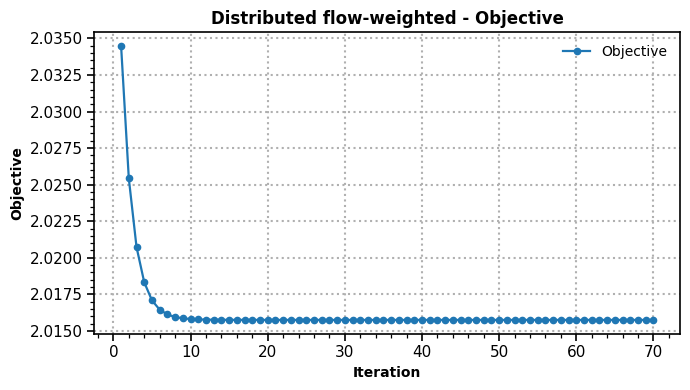

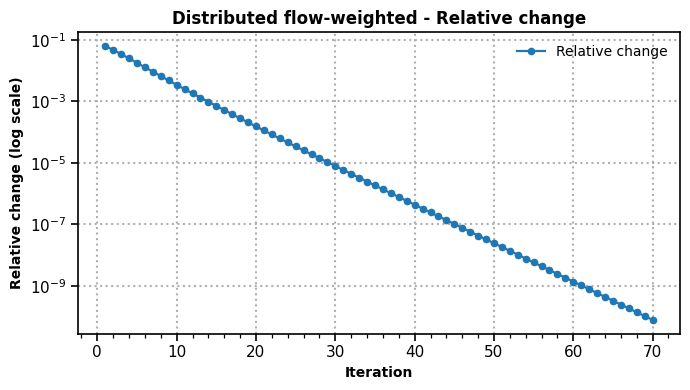

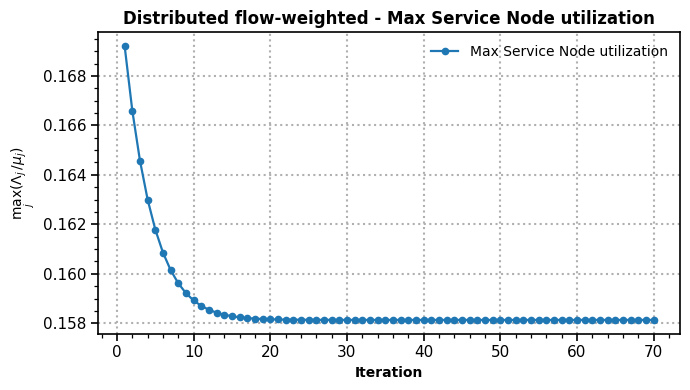

In [7]:
# ------------------------------------------------------------
# 10) Convergence plots for distributed solver (paper-like)
# ------------------------------------------------------------
# Colab-safe: ensure plots render
# (optional) %matplotlib inline


def _stylize_axes(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # dotted grid similar to your screenshot
    ax.grid(True, which="major", linestyle=":", linewidth=1.5)
    ax.minorticks_on()

    # slightly thicker spines/ticks for a paper look
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=11)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)

def plot_history(history, title, filename=None, marker="o", markersize=4.5):
    iters = np.arange(1, len(history["objective"]) + 1)

    # Guard: nothing to plot
    if len(iters) == 0:
        print(f"[plot_history] Empty history for: {title}")
        return

    # ---------- Objective ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, history["objective"],
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Objective"
    )
    _stylize_axes(ax, "Iteration", "Objective", f"{title} - Objective")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_obj.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_obj.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / 'ObjvsIter.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ---------- Relative change (log) ----------
    rel = np.asarray(history["rel_change"], dtype=float)
    rel = np.maximum(rel, 1e-16)  # avoid log(0) which can blank plots

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, rel,
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Relative change"
    )
    ax.set_yscale("log")
    _stylize_axes(ax, "Iteration", "Relative change (log scale)", f"{title} - Relative change")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_relchange.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_relchange.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / 'RelchangevsIter.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    # ---------- Max broker utilization ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        iters, history["max_broker_util"],
        linestyle="-", linewidth=1.6,
        marker=marker, markersize=markersize,
        label="Max Service Node utilization"
    )
    _stylize_axes(ax, "Iteration", r"$\max_j(\Lambda_j/\mu_j)$", f"{title} - Max Service Node utilization")
    ax.legend(frameon=False)
    fig.tight_layout()
    if filename:
        fig.savefig(filename + "_util.png", dpi=300, bbox_inches="tight")
        fig.savefig(filename + "_util.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / 'MaxBrokerUtil.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Only flow-weighted remains
plot_history(dist_flow["history"], "Distributed flow-weighted", marker="o")


,Central,Distributed (final)
SN1,0.1581,0.1581
SN2,0.1386,0.1386
SN3,0.1030,0.1030


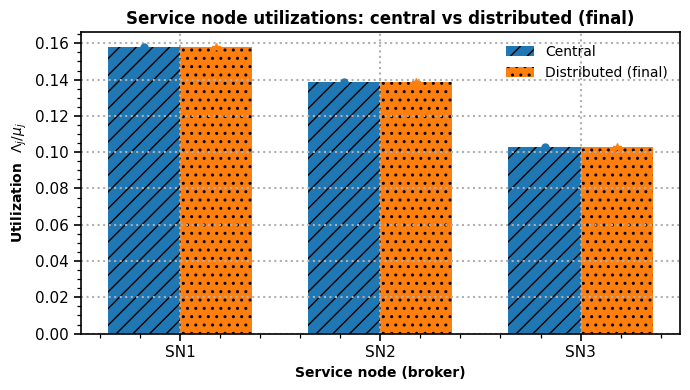

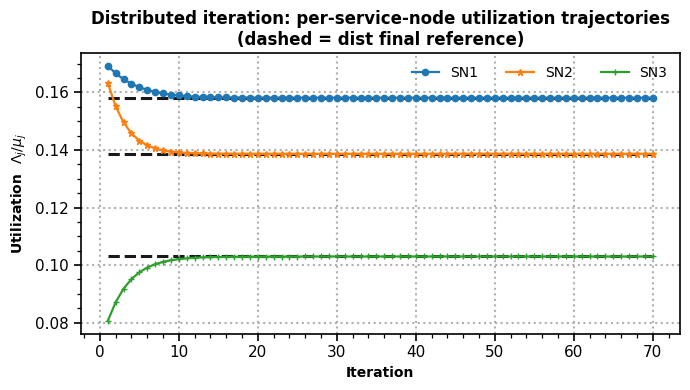

In [8]:
# ============================================================
# (NEW) Service node (broker) utilization plots for comparison
# Uses existing: L_flow_central, dist_flow["L"], MU_brokers, brokers_list, _stylize_axes
# ============================================================


# ---- (A) numbers (optional small table, consistent with what you already had)
util_central = L_flow_central.sum(axis=0) / MU_brokers
util_dist    = dist_flow["L"].sum(axis=0) / MU_brokers

df_util_compare = pd.DataFrame(
    {"Central": util_central, "Distributed (final)": util_dist},
    index=brokers_list
).round(4)

display(df_util_compare)

# ---- (B) bar chart: central vs distributed (final)
x = np.arange(len(brokers_list))
w = 0.36

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, util_central, width=w, label="Central", hatch="//")
ax.bar(x + w/2, util_dist,    width=w, label="Distributed (final)", hatch="..")

# optional: put markers on top of bars (keeps your “shape” consistency)
ax.plot(x - w/2, util_central, linestyle="None", marker="o", markersize=5)
ax.plot(x + w/2, util_dist,    linestyle="None", marker="*", markersize=6)

ax.set_xticks(x)
ax.set_xticklabels(brokers_list)

_stylize_axes(ax, "Service node (broker)", r"Utilization  $\Lambda_j/\mu_j$",
              "Service node utilizations: central vs distributed (final)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'PerBrokerUtils.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ---- (C) trajectories over distributed iterations (per-service-node utilization)
U = np.asarray(dist_flow["history"]["broker_utils"], dtype=float)  # (T, n)
iters = np.arange(1, U.shape[0] + 1)

# reference (deterministic distributed final utilization per broker)
util_ref = dist_flow["L"].sum(axis=0) / MU_brokers   # shape (n,)

fig, ax = plt.subplots(figsize=(7, 4))
markers = ["o", "*", "+", "x", "D"]

for j, b in enumerate(brokers_list):
    ax.plot(
        iters, U[:, j],
        linestyle="-", linewidth=1.6,
        marker=markers[j % len(markers)], markersize=4.5,
        label=f"{b}"
    )
    # dashed reference line for this broker
    ax.hlines(
        util_ref[j],
        iters[0], iters[-1],
        linestyles="--",
        linewidth=2.2,
        color="k",
        alpha=0.9,
        zorder=0
    )

_stylize_axes(
    ax, "Iteration", r"Utilization  $\Lambda_j/\mu_j$",
    "Distributed iteration: per-service-node utilization trajectories\n(dashed = dist final reference)"
)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'PerBrokerUtil_vsIter_DistRef.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)



,central_mean_delay,dist_mean_delay,abs_gap,rel_gap
P0,0.028947,0.028947,0.0,0.0
P1,0.030477,0.030477,0.0,0.0
P2,0.032973,0.032973,0.0,0.0
P3,0.033804,0.033804,0.0,0.0
P4,0.024999,0.024999,0.0,0.0


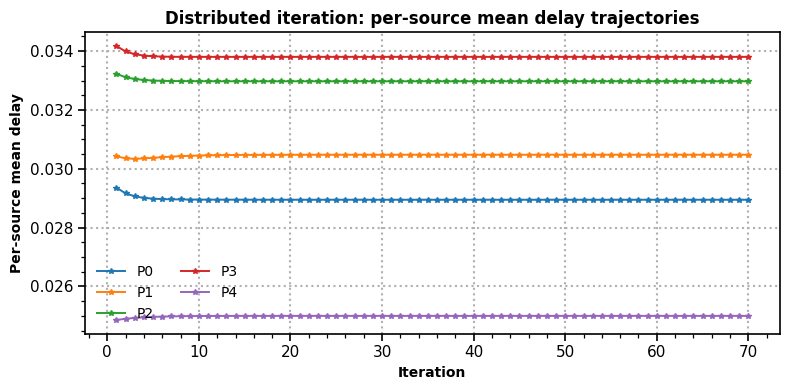

In [9]:
# ============================================================
# Plotting per-source mean delays:
#   (A) table (central vs dist final)
#   (B) bar chart
#   (C) trajectories over iterations (dist), with central reference
# ============================================================


def per_source_mean_delay(L, lambdas_total, MU_links, MU_brokers, eps=1e-12):
    """
    Returns:
      mean_i: shape (m,)  mean delay for each source i, weighted by its own flow split
      e2e_ij: shape (m,n) per-path delay D_ij(λ_ij)+D_j(Λ_j)
      access_ij: shape (m,n) access delay D_ij(λ_ij)
      broker_j: shape (n,)  broker delay D_j(Λ_j)
    """
    L = np.asarray(L, dtype=float)
    m, n = L.shape
    s = L.sum(axis=0)

    access_ij = 1.0 / np.maximum(MU_links - L, eps)                  # D_ij(λ_ij)
    broker_j  = 1.0 / np.maximum(MU_brokers - s, eps)                # D_j(Λ_j)
    delay_ij    = access_ij + broker_j[None, :]                        # D_ij + D_j

    mean_i = np.zeros(m, dtype=float)
    for i in range(m):
        denom = max(lambdas_total[i], eps)
        mean_i[i] = float((L[i, :] * delay_ij[i, :]).sum() / denom)

    return mean_i, delay_ij, access_ij, broker_j


# ---- (A) table: central vs dist final
mean_central, _, _, _ = per_source_mean_e2e(L_flow_central, lambdas_total, MU_links, MU_brokers)
mean_dist,    _, _, _ = per_source_mean_e2e(dist_flow["L"],  lambdas_total, MU_links, MU_brokers)

df_src = pd.DataFrame({
    "central_mean_delay": mean_central,
    "dist_mean_delay": mean_dist,
    "abs_gap": np.abs(mean_dist - mean_central),
    "rel_gap": np.abs(mean_dist - mean_central) / np.maximum(mean_central, 1e-12),
}, index=producers_list)

display(df_src.round(6))

"""
# ---- (B) bar chart: per-source mean delay (central vs dist final)
x = np.arange(len(producers_list))
w = 0.38

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - w/2, mean_central, width=w, label="Central")
ax.bar(x + w/2, mean_dist,    width=w, label="Distributed (final)")

ax.set_xticks(x)
ax.set_xticklabels(producers_list)
ax.set_xlabel("Source (producer)")
ax.set_ylabel("Mean delay (flow-weighted)")
ax.set_title("Per-source mean delay: central vs distributed (final)")
ax.grid(True, which="major", linestyle=":", linewidth=1.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
plt.close(fig)
"""

# ---- (C) trajectories: per-source mean delay over distributed iterations
S = np.asarray(dist_flow["history"]["source_mean_delay"], dtype=float)   # shape (T, m)
iters = np.arange(1, S.shape[0] + 1)

fig, ax = plt.subplots(figsize=(8,4))
for i, p in enumerate(producers_list):
    ax.plot(
        iters, S[:, i],
        marker="*", markersize=3.8,
        linewidth=1.4,
        label=f"{p}"
    )

# styling: match other diags
try:
    _stylize_axes(
        ax,
        "Iteration",
        "Per-source mean delay",
        "Distributed iteration: per-source mean delay trajectories"
    )
except NameError:
    ax.set_xlabel("Iteration", fontweight="bold")
    ax.set_ylabel("Per-source mean delay", fontweight="bold")
    ax.set_title("Distributed iteration: per-source mean delay trajectories", fontweight="bold")
    ax.grid(True, which="major", linestyle=":", linewidth=1.2)

ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / 'PerSourceMeanDelay_vsIter.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)




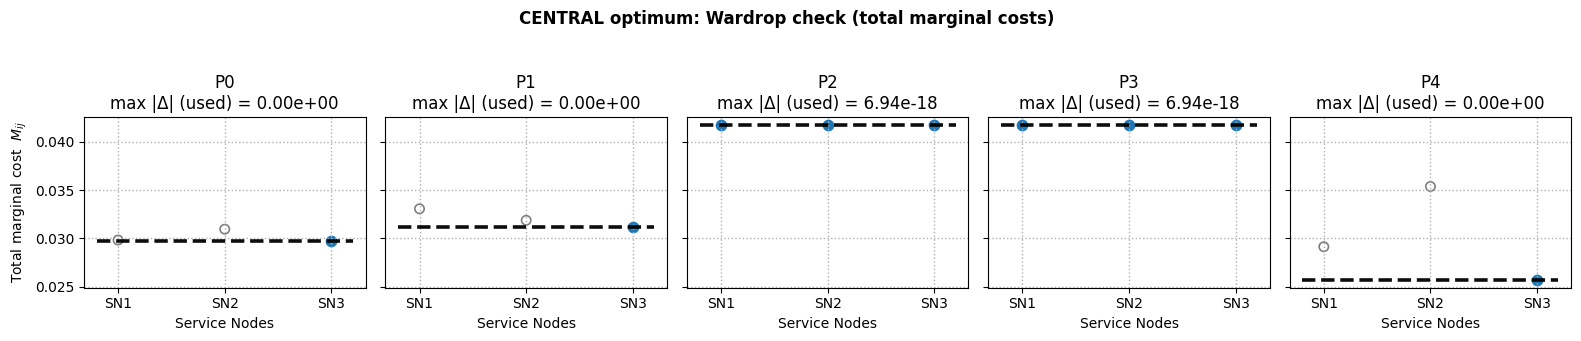

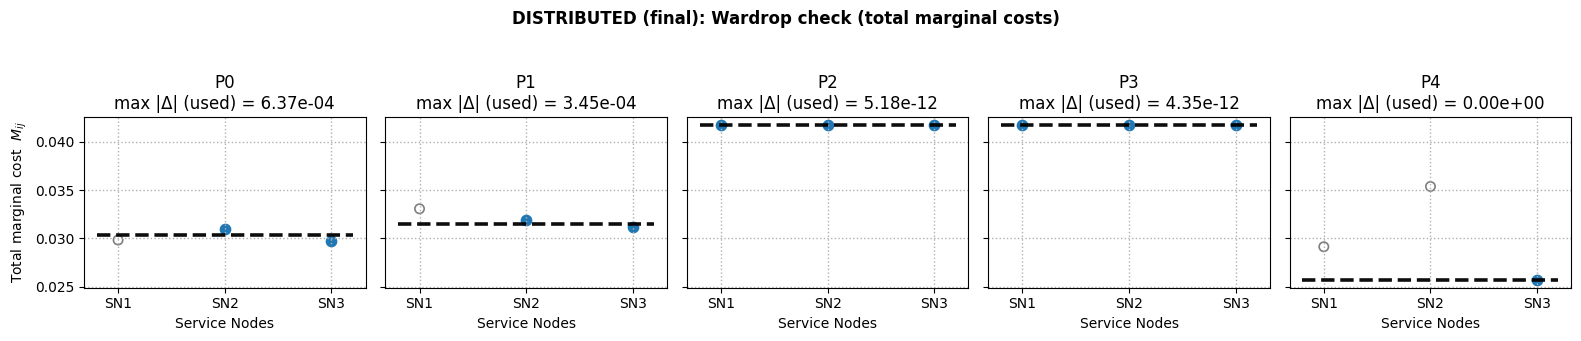

In [10]:
def wardrop_marginals_mm1(L, MU_links, MU_brokers, eps=1e-8):
    """
    Returns:
      M_total: (m,n) total marginal costs M_ij
      C_access: (m,n) access marginal costs
      C_server: (n,)  server marginal costs (prices)
      Lambda:  (n,)   broker loads
    """
    L = np.asarray(L, dtype=float)
    MU_links = np.asarray(MU_links, dtype=float)
    MU_brokers = np.asarray(MU_brokers, dtype=float)

    Lambda = L.sum(axis=0)  # (n,)

    # Access marginal: mu_ij / (mu_ij - lambda_ij)^2
    denom_link = np.maximum(MU_links - L, 3*eps)
    C_access = MU_links / (denom_link**2)

    # Server marginal: mu_j / (mu_j - Lambda_j)^2
    denom_srv = np.maximum(MU_brokers - Lambda, 3*eps)
    C_server = MU_brokers / (denom_srv**2)

    M_total = C_access + C_server[None, :]
    return M_total, C_access, C_server, Lambda


def plot_wardrop_per_source(M_total, L, producers_list, brokers_list,
                            title="Wardrop check: total marginal costs per source",
                            used_thresh=1e-10):
    """
    For each source i, plot M_ij across brokers j.
    Used routes (lambda_ij > used_thresh) are emphasized.
    Dashed black line = mean marginal cost over USED routes for that source.
    """
    L = np.asarray(L, dtype=float)
    M_total = np.asarray(M_total, dtype=float)

    m, n = M_total.shape
    x = np.arange(n)

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        used = L[i, :] > used_thresh

        # plot all brokers
        ax.scatter(x[~used], M_total[i, ~used], marker="o", facecolors="none",
                   edgecolors="tab:gray", linewidths=1.2, s=45, label="unused")
        ax.scatter(x[used],  M_total[i, used],  marker="o",
                   s=55, label="used")

        # Wardrop reference: mean over used paths
        if np.any(used):
            ref = float(M_total[i, used].mean())
            ax.hlines(ref, x[0]-0.2, x[-1]+0.2, linestyles="--",
                      color="k", linewidth=2.6, alpha=0.95)

            # show max deviation among used
            dev = np.max(np.abs(M_total[i, used] - ref))
            ax.set_title(f"{producers_list[i]}\nmax |Δ| (used) = {dev:.2e}")
        else:
            ax.set_title(f"{producers_list[i]}\n(no used routes?)")

        ax.set_xticks(x)
        ax.set_xticklabels(brokers_list, rotation=0)
        ax.grid(True, linestyle=":", linewidth=1.0)
        ax.set_xlabel("Service Nodes")

    axes[0].set_ylabel("Total marginal cost  $M_{ij}$")
    fig.suptitle(title, y=1.05, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# --- CENTRAL Wardrop check ---
M_c, _, p_c, Lambda_c = wardrop_marginals_mm1(L_flow_central, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_c, L_flow_central,
    producers_list, brokers_list,
    title="CENTRAL optimum: Wardrop check (total marginal costs)"
)

# --- DISTRIBUTED (final iterate) Wardrop check ---
L_dist = dist_flow["L"]
M_d, _, p_d, Lambda_d = wardrop_marginals_mm1(L_dist, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_d, L_dist,
    producers_list, brokers_list,
    title="DISTRIBUTED (final): Wardrop check (total marginal costs)"
)


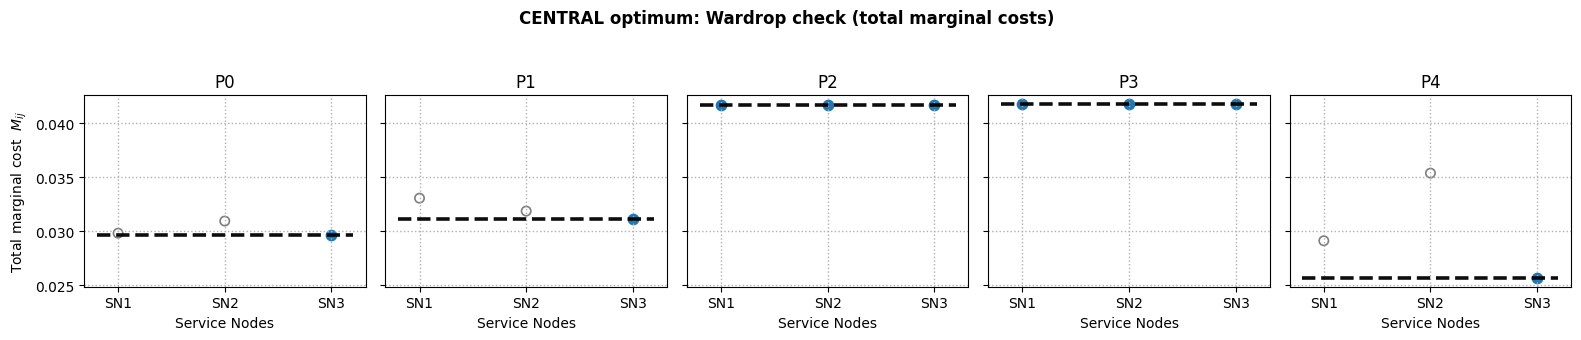

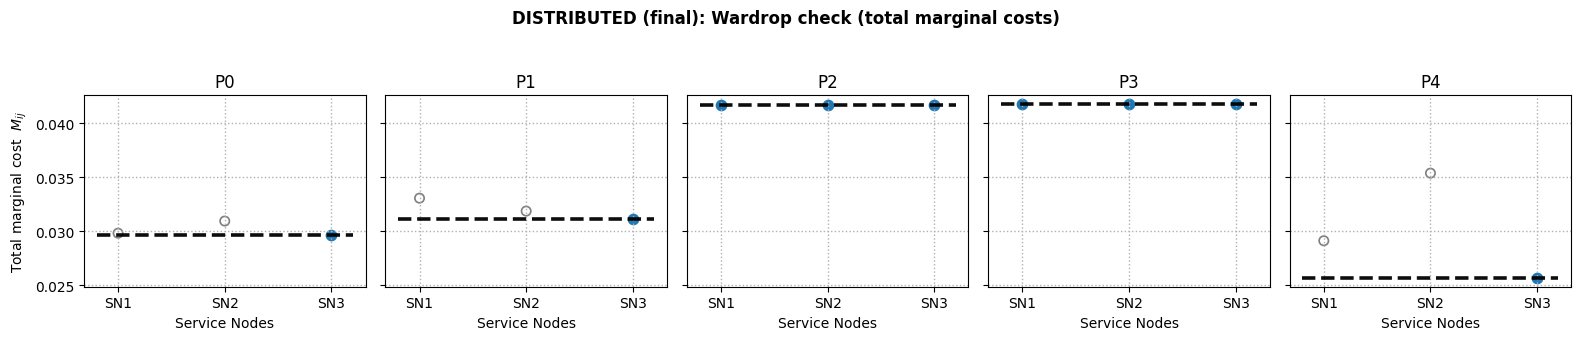

In [11]:
def plot_wardrop_per_source(M_total, L, lambdas_total, producers_list, brokers_list,
                            title="Wardrop check: total marginal costs per source",
                            used_rel=1e-3, used_abs=1e-6):
    """
    used if lambda_ij >= max(used_abs, used_rel * lambda_i)
    Dashed black line = mean marginal cost over USED routes for that source.
    (Option A) No per-panel "max |Δ| (used)" annotation in titles.
    """
    L = np.asarray(L, dtype=float)
    M_total = np.asarray(M_total, dtype=float)
    lambdas_total = np.asarray(lambdas_total, dtype=float)

    m, n = M_total.shape
    x = np.arange(n)

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        thresh_i = max(float(used_abs), float(used_rel) * float(lambdas_total[i]))
        used = L[i, :] >= thresh_i

        # plot unused vs used
        ax.scatter(
            x[~used], M_total[i, ~used],
            marker="o", facecolors="none",
            edgecolors="tab:gray", linewidths=1.2, s=45
        )
        ax.scatter(
            x[used], M_total[i, used],
            marker="o", s=55
        )

        # Wardrop reference: mean over used paths
        if np.any(used):
            ref = float(M_total[i, used].mean())
            ax.hlines(
                ref, x[0]-0.2, x[-1]+0.2,
                linestyles="--", color="k",
                linewidth=2.6, alpha=0.95
            )
            ax.set_title(f"{producers_list[i]}")
        else:
            ax.set_title(f"{producers_list[i]}")

        ax.set_xticks(x)
        ax.set_xticklabels(brokers_list)
        ax.grid(True, linestyle=":", linewidth=1.0)
        ax.set_xlabel("Service Nodes")

    axes[0].set_ylabel(r"Total marginal cost  $M_{ij}$")
    fig.suptitle(title, y=1.05, fontweight="bold")
    fig.tight_layout()
    wardrop_name = ('WardropCheck_Central_TotalMarginal.png' if title.startswith('CENTRAL') else 'WardropCheck_Distributed_TotalMarginal.png')
    fig.savefig(FIG_DIR / wardrop_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# CENTRAL
M_c, _, _, _ = wardrop_marginals_mm1(L_flow_central, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_c, L_flow_central, lambdas_total, producers_list, brokers_list,
    title="CENTRAL optimum: Wardrop check (total marginal costs)"
)

# DISTRIBUTED (final)
L_dist = dist_flow["L"]
M_d, _, _, _ = wardrop_marginals_mm1(L_dist, MU_links, MU_brokers, eps=eps)
plot_wardrop_per_source(
    M_d, L_dist, lambdas_total, producers_list, brokers_list,
    title="DISTRIBUTED (final): Wardrop check (total marginal costs)"
)


In [12]:
# ============================================================
# Windowed Stochastic simulation of the DISTRIBUTED pricing scheme
# - Poisson arrivals per producer
# - Random (or RR) splitting according to x_ij(t)
# - Per-(i,j) access queue + per-broker server queue
# - Broker EWMA estimates arrival rate -> price p_j(t)
# - Producers recompute best-response split each window (synchronous)
# ============================================================

# ------------------------
# Keep these SAME as before
# ------------------------
SIM_DURATION_SEC = 300
TIME_WINDOW      = 5
WARMUP_WINDOWS   = 4

# ------------------------
# New stochastic knobs (report these)
# ------------------------
PACKET_MB   = 1.0     # 1 packet = 1 MB of traffic
BETA_LAMBDA = 0.30    # EWMA smoothing for broker arrival-rate estimate
GAMMA_PRICE = 0.50    # optional smoothing on prices p_j
ETA_SPLIT   = 0.35    # inertia on split update (like damping for x_ij)

ROUTING_MODE = "random"   # "random" (recommended) or "round_robin"

np.random.seed(42)

# ------------------------
# Convert rates from MB/s -> packets/s
# ------------------------
lambdas_pkt     = np.asarray(lambdas_total_MB, dtype=float) / PACKET_MB     # (m,)
MU_links_pkt    = np.asarray(MU_links_MB, dtype=float) / PACKET_MB          # (m,n)
MU_brokers_pkt  = np.asarray(MU_brokers_MB, dtype=float) / PACKET_MB        # (n,)

m, n = MU_links_pkt.shape
dt = float(TIME_WINDOW)
T  = int(SIM_DURATION_SEC // TIME_WINDOW)

eps = 1e-9

# ------------------------
# Initialize split x_ij from your feasible L0 (if you already have it).
# If L0 doesn't exist in your notebook state, fall back to proportional-to-cap.
# ------------------------
try:
    # L0 in MB/s -> convert to packets/s
    L0_pkt = (L0 / PACKET_MB).copy()
    x = L0_pkt / np.maximum(lambdas_pkt[:, None], eps)
except NameError:
    # fallback: x_ij ∝ MU_links_ij
    x = MU_links_pkt / np.maximum(MU_links_pkt.sum(axis=1, keepdims=True), eps)

# ensure rows sum to 1
x = np.maximum(x, 0.0)
x = x / np.maximum(x.sum(axis=1, keepdims=True), eps)

# ------------------------
# Best-response solver
# Reuse the verified piecewise best_response_mm1 defined in Phase 3.

# ------------------------
# Routing allocation within each window
# ------------------------
rr_ptr = np.zeros(m, dtype=int)

def allocate_counts(A_i, probs, mode="random", i=None):
    probs = np.asarray(probs, dtype=float)
    probs = np.maximum(probs, 0.0)
    probs = probs / np.maximum(probs.sum(), eps)

    if A_i <= 0:
        return np.zeros_like(probs, dtype=int)

    if mode == "random":
        return np.random.multinomial(A_i, probs)

    # round-robin approx for target proportions
    counts = np.floor(A_i * probs).astype(int)
    rem = int(A_i - counts.sum())
    if rem > 0:
        start = rr_ptr[i] if i is not None else 0
        order = (start + np.arange(len(probs))) % len(probs)
        for k in range(rem):
            counts[order[k % len(probs)]] += 1
        if i is not None:
            rr_ptr[i] = (start + rem) % len(probs)
    return counts

# ------------------------
# State: queues
# ------------------------
q_link   = np.zeros((m, n), dtype=int)   # per-(i,j) access queue length (packets)
q_broker = np.zeros(n, dtype=int)        # per-broker queue length (packets)

# EWMA arrival-rate estimate at brokers (packets/s)
Lambda_hat = np.zeros(n, dtype=float)

# prices
p = np.zeros(n, dtype=float)

# ------------------------
# History for plots + comparisons
# ------------------------
hist_time       = np.arange(T) * dt
hist_p          = np.zeros((T, n), dtype=float)
hist_util       = np.zeros((T, n), dtype=float)   # <-- USED BY YOUR COMPARISON CELL
hist_q_broker   = np.zeros((T, n), dtype=float)
hist_mean_delay = np.zeros((T, m), dtype=float)
hist_x          = np.zeros((T, m, n), dtype=float)

def delay_from_queue(q, mu):
    # rough instantaneous sojourn estimate: (q/mu) + (1/mu)
    mu = np.maximum(mu, 1e-12)
    return (q / mu) + (1.0 / mu)

# ------------------------
# Main synchronous loop
# ------------------------
for t_idx in range(T):
    # 1) Producer arrivals (packets in this window)
    A_i = np.random.poisson(lambdas_pkt * dt)   # (m,)

    # split into paths
    A_ij = np.zeros((m, n), dtype=int)
    for i in range(m):
        A_ij[i, :] = allocate_counts(int(A_i[i]), x[i, :], mode=ROUTING_MODE, i=i)

    # 2) Access/link queues: add arrivals, serve
    dep_link = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            q_link[i, j] += A_ij[i, j]
            svc = np.random.poisson(MU_links_pkt[i, j] * dt)
            served = min(q_link[i, j], int(svc))
            q_link[i, j] -= served
            dep_link[i, j] = served

    # 3) Broker queues: arrivals = sum departures from links, serve
    arrivals_broker = dep_link.sum(axis=0).astype(int)  # (n,)
    dep_broker = np.zeros(n, dtype=int)
    for j in range(n):
        q_broker[j] += arrivals_broker[j]
        svc = np.random.poisson(MU_brokers_pkt[j] * dt)
        served = min(q_broker[j], int(svc))
        q_broker[j] -= served
        dep_broker[j] = served

    # 4) Broker EWMA arrival-rate estimate -> price update
    inst_rate = arrivals_broker / dt  # packets/s
    Lambda_hat = (1.0 - BETA_LAMBDA) * Lambda_hat + BETA_LAMBDA * inst_rate

    p_inst = MU_brokers_pkt / np.maximum(MU_brokers_pkt - Lambda_hat, 1e-6)**2
    p = (1.0 - GAMMA_PRICE) * p + GAMMA_PRICE * p_inst

    # 5) Producer split update after warmup (best-response + inertia)
    if t_idx >= WARMUP_WINDOWS:
        x_target = np.zeros((m, n), dtype=float)
        for i in range(m):
            lam_br = best_response_mm1(MU_links_pkt[i, :], p, lambdas_pkt[i])
            x_target[i, :] = lam_br / np.maximum(lambdas_pkt[i], eps)

        x = (1.0 - ETA_SPLIT) * x + ETA_SPLIT * x_target
        x = np.maximum(x, 0.0)
        x = x / np.maximum(x.sum(axis=1, keepdims=True), eps)

    # 6) Record delay/util/splits
    util = Lambda_hat / np.maximum(MU_brokers_pkt, 1e-12)

    d_link = delay_from_queue(q_link.astype(float), MU_links_pkt)      # (m,n)
    d_srv  = delay_from_queue(q_broker.astype(float), MU_brokers_pkt)  # (n,)
    d_e2e  = d_link + d_srv[None, :]                                   # (m,n)
    mean_delay_i = (x * d_e2e).sum(axis=1)                             # (m,)

    hist_p[t_idx, :]          = p
    hist_util[t_idx, :]       = util
    hist_q_broker[t_idx, :]   = q_broker
    hist_mean_delay[t_idx, :] = mean_delay_i
    hist_x[t_idx, :, :]       = x

print("Done. Stochastic simulation finished.")
print("Routing mode:", ROUTING_MODE, "| PACKET_MB:", PACKET_MB)
print("T windows:", T, "| window:", dt, "sec | warmup windows:", WARMUP_WINDOWS)


Done. Stochastic simulation finished.
Routing mode: random | PACKET_MB: 1.0
T windows: 60 | window: 5.0 sec | warmup windows: 4


max q_broker per broker: [0. 0. 0.]
mean q_broker per broker: [0. 0. 0.]
fraction nonzero per broker: [0. 0. 0.]

Average split x_ij after warmup:
P0 : {'SN1': 0.00011010343239974376, 'SN2': 0.03316326530492475, 'SN3': 0.9667266312626752}
P1 : {'SN1': 0.0, 'SN2': 0.03316326530507994, 'SN3': 0.9668367346949199}
P2 : {'SN1': 0.5082567071895646, 'SN2': 0.1611959712964278, 'SN3': 0.33054732151400745}
P3 : {'SN1': 0.34139938335943826, 'SN2': 0.3319240182814225, 'SN3': 0.3266765983591391}
P4 : {'SN1': 0.0, 'SN2': 0.0, 'SN3': 1.0}

Deterministic dist split x_ij (from dist_flow['L']):
P0 : {'SN1': 0.0, 'SN2': 1.795925998137979e-09, 'SN3': 0.9999999982051481}
P1 : {'SN1': 0.0, 'SN2': 1.79592599813798e-09, 'SN3': 0.99999999820617}
P2 : {'SN1': 0.5048734728370532, 'SN2': 0.16248800888690232, 'SN3': 0.33263851827622876}
P3 : {'SN1': 0.34139632668455083, 'SN2': 0.3292909060662918, 'SN3': 0.3293127672487207}
P4 : {'SN1': 0.0, 'SN2': 0.0, 'SN3': 1.0000000000010087}


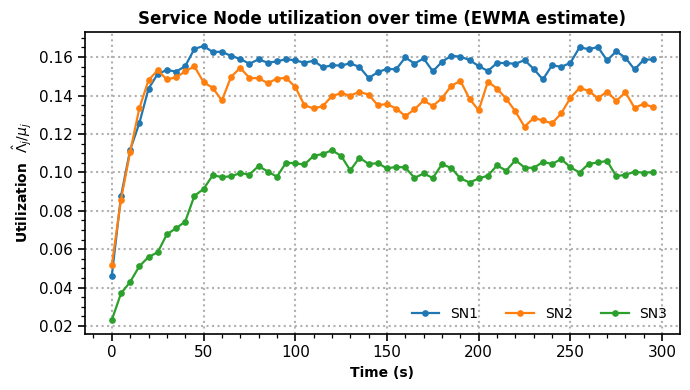

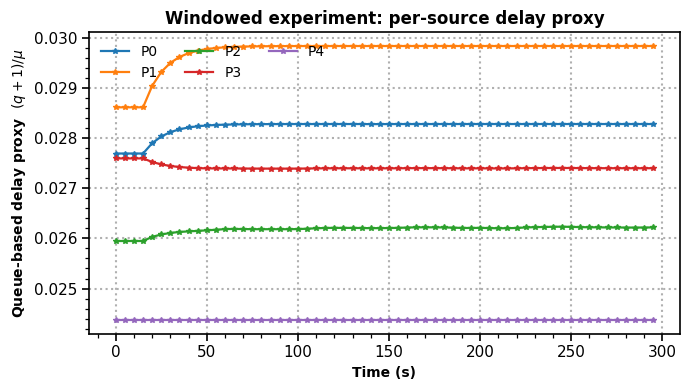

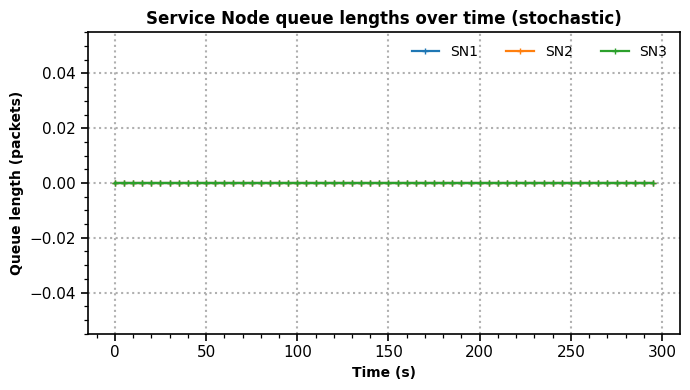

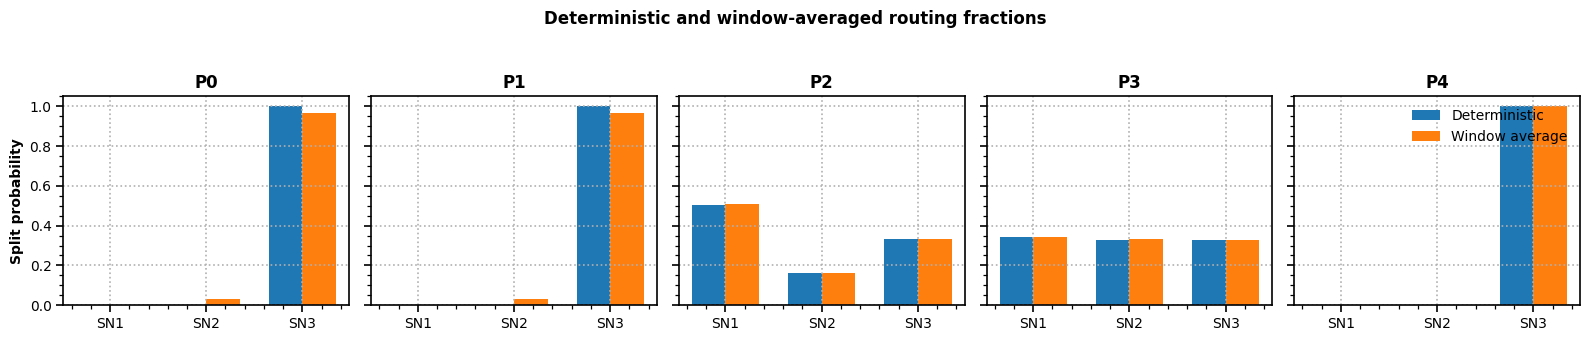

In [13]:
# ============================================================
# Plots: utilities, delays, splits over time  (STYLE CONSISTENT)
# ============================================================


# Reuse this if you already defined it earlier; otherwise keep this definition.
def _stylize_axes(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, which="major", linestyle=":", linewidth=1.5)
    ax.minorticks_on()
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=11)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)

def plot_time_series_multi(ax, t, Y, labels, marker="o", markersize=4.5, linewidth=1.6):
    """
    Y: shape (T, k). Plots k lines with a consistent style.
    """
    for k, lab in enumerate(labels):
        ax.plot(
            t, Y[:, k],
            linestyle="-",
            linewidth=linewidth,
            marker=marker,
            markersize=markersize,
            label=str(lab),
        )

# (1) Broker utilization over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_util,
    labels=brokers_list,
    marker="o", markersize=3.8, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", r"Utilization  $\hat\Lambda_j/\mu_j$",
             "Service Node utilization over time (EWMA estimate)")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'Stoch_BrokerUtilEWMA_vsTime.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# (2) Per-producer mean end-to-end delay over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_mean_delay,
    labels=producers_list,
    marker="*", markersize=3.8, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", r"Queue-based delay proxy  $(q+1)/\mu$",
             "Windowed experiment: per-source delay proxy")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'Stoch_PerSourceMeanDelay_vsTime.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# (3) Broker queue lengths over time
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_series_multi(
    ax, hist_time, hist_q_broker,
    labels=brokers_list,
    marker="+", markersize=5.0, linewidth=1.6
)
_stylize_axes(ax, "Time (s)", "Queue length (packets)",
             "Service Node queue lengths over time (stochastic)")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'Stoch_QueueLen_vsTime.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print("max q_broker per broker:", hist_q_broker.max(axis=0))
print("mean q_broker per broker:", hist_q_broker.mean(axis=0))
print("fraction nonzero per broker:", (hist_q_broker > 0).mean(axis=0))


# (4) Average split per producer after warmup (deterministic vs stochastic avg)
t0 = WARMUP_WINDOWS
x_avg = hist_x[t0:, :, :].mean(axis=0)   # (m,n)

print("\nAverage split x_ij after warmup:")
for i, p_name in enumerate(producers_list):
    print(p_name, ":", {brokers_list[j]: float(x_avg[i,j]) for j in range(n)})

# Optional: compare against deterministic distributed solution "dist_flow['L']"
try:
    L_det = dist_flow["L"]  # MB/s
    x_det = (L_det / np.maximum(lambdas_total_MB[:, None], 1e-12))

    print("\nDeterministic dist split x_ij (from dist_flow['L']):")
    for i, p_name in enumerate(producers_list):
        print(p_name, ":", {brokers_list[j]: float(x_det[i,j]) for j in range(n)})

    fig, axes = plt.subplots(1, m, figsize=(3.2*m, 3.2), sharey=True)
    if m == 1:
        axes = [axes]
    x_idx = np.arange(n)
    w = 0.35

    for i, ax in enumerate(axes):
        ax.bar(x_idx - w/2, x_det[i,:], width=w, label="Deterministic")
        ax.bar(x_idx + w/2, x_avg[i,:], width=w, label="Window average")
        ax.set_xticks(x_idx)
        ax.set_xticklabels(brokers_list)
        ax.set_title(producers_list[i], fontweight="bold")
        ax.grid(True, which="major", linestyle=":", linewidth=1.2)
        ax.minorticks_on()
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
        ax.tick_params(axis="both", which="major", width=1.2, length=5, labelsize=10)
        ax.tick_params(axis="both", which="minor", width=0.9, length=3)

    axes[0].set_ylabel("Split probability", fontweight="bold")
    axes[-1].legend(frameon=False, loc="upper right")
    fig.suptitle("Deterministic and window-averaged routing fractions", y=1.05, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'RateSplit_Dist_vs_Stoch.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

except NameError:
    pass


In [14]:
# deterministic final utilization (from dist solver)
u_det = dist_flow["L"].sum(axis=0) / MU_brokers_MB   # shape (n,)

# stochastic utilization trace: hist_util is (T, n)
U_post = hist_util[WARMUP_WINDOWS:, :]              # post-warmup only

u_mean = U_post.mean(axis=0)
u_std  = U_post.std(axis=0, ddof=1)                 # sample std

df = pd.DataFrame({
    "u_det": u_det,
    "u_stoch_mean": u_mean,
    "u_stoch_std": u_std,
    "abs_gap": np.abs(u_mean - u_det),
    "rel_gap": np.abs(u_mean - u_det) / np.maximum(u_det, 1e-12),
}, index=brokers_list)

display(df.round(6))


,u_det,u_stoch_mean,u_stoch_std,abs_gap,rel_gap
SN1,0.158136,0.157111,0.004296,0.001025,0.006482
SN2,0.138642,0.140279,0.007660,0.001637,0.011806
SN3,0.102983,0.098438,0.011471,0.004545,0.044134


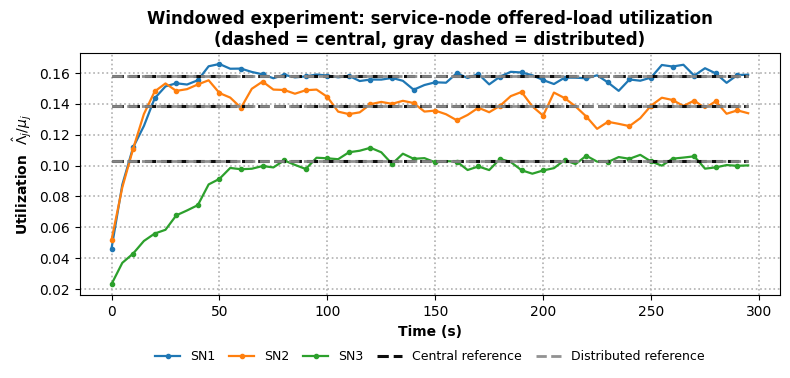

In [15]:
# (1) Broker utilization over time + deterministic references (central + dist)
fig, ax = plt.subplots(figsize=(8,4))

mark_every = max(1, len(hist_time)//25)  # ~25 markers across the plot

# stochastic EWMA utilization trajectories
for j, b in enumerate(brokers_list):
    ax.plot(
        hist_time, hist_util[:, j],
        linewidth=1.6,
        marker="o", markersize=3.0,
        markevery=mark_every,
        label=b
    )

# references
util_dist = dist_flow["L"].sum(axis=0) / np.maximum(MU_brokers_MB, 1e-12)
util_cent = L_flow_central.sum(axis=0) / np.maximum(MU_brokers_MB, 1e-12)

# central ref (black dashed)
for j in range(len(brokers_list)):
    ax.hlines(
        util_cent[j], hist_time[0], hist_time[-1],
        linestyles="--", linewidth=2.2, color="k", alpha=0.95,
        label="Central reference" if j == 0 else None
    )

# dist-final ref (gray dashed)
for j in range(len(brokers_list)):
    ax.hlines(
        util_dist[j], hist_time[0], hist_time[-1],
        linestyles="--", linewidth=2.0, color="0.55", alpha=0.95,
        label="Distributed reference" if j == 0 else None
    )

# styling
ax.set_xlabel("Time (s)", fontweight="bold")
ax.set_ylabel(r"Utilization  $\hat\Lambda_j/\mu_j$", fontweight="bold")
ax.set_title("Windowed experiment: service-node offered-load utilization\n(dashed = central, gray dashed = distributed)", fontweight="bold")
ax.grid(True, linestyle=":", linewidth=1.2)

# ---- legend: outside + compact ----
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    frameon=False,
    ncol=5,                 # B0 B1 B2 Central Dist
    fontsize=9,
    handlelength=2.0,
    columnspacing=1.1,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18)  # push legend below axes
)

fig.tight_layout()
fig.savefig(FIG_DIR / 'Stoch_BrokerUtilEWMA_vsTime_DistRef.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
